<a href="https://colab.research.google.com/github/Gurekamjot003/Delta-Hedging-Adversarial-Stock-Path-Generation-Simulator/blob/main/HFT_CAMP_CODE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Uploading a CSV file to Google Colab

1.  **Click the 'Files' icon** on the left sidebar (it looks like a folder).
2.  **Click the 'Upload to session storage' icon** (it looks like a file with an arrow pointing up) and select your CSV file.
3.  Once uploaded, you can find the file in the `/content/` directory.

After you've uploaded the file (e.g., `your_file_05_feb.csv`), you can load it into a pandas DataFrame like this:

In [ ]:
from google.colab import files

uploaded = files.upload()

# Get the name of the uploaded file
if uploaded:
    uploaded_file_name = list(uploaded.keys())[0]
    print(f"File '{uploaded_file_name}' uploaded successfully.")
else:
    print("No file was uploaded.")

Saving 20260205_option_minute_prices_expiry.csv to 20260205_option_minute_prices_expiry.csv
File '20260205_option_minute_prices_expiry.csv' uploaded successfully.


In [ ]:
import pandas as pd

# Use the name of the uploaded file to load the DataFrame
file_name = uploaded_file_name
df_feb05 = pd.read_csv(file_name)

print(f"Successfully loaded '{file_name}' into a DataFrame.")

# Display the first 5 rows to verify
display(df_feb05.head())

Successfully loaded '20260205_option_minute_prices_expiry.csv' into a DataFrame.


,date,minute_end,symbol,last_trade_price
0,20260205,91600,NIFTY26FEBFUT,2578540.0
1,20260205,91600,NIFTY2621025600CE,23115.0
2,20260205,91600,NIFTY2621025650CE,19995.0
3,20260205,91600,NIFTY2621025700CE,17140.0
4,20260205,91600,NIFTY2621025750CE,14535.0


### Filter Data and Setup Simulation Parameters
We now extract future prices and option contract symbols from our loaded session dataset. The symbols are parsed to derive strike prices and option types (Call/Put), and the underlying price and option premiums are scaled from paise to rupees for standardized model computations.

### Step 1: Filter Data and Extract Futures Price

First, we'll filter the DataFrame for options data at 11:00:00 (which corresponds to `minute_end = 110000`). We'll also extract the future price and parse the option symbols to get the strike prices and whether they are Call (CE) or Put (PE) options.

In [ ]:
import numpy as np
import pandas as pd

# Filter for 11 AM (11:00:00)
filtered_df = df_feb05[df_feb05['minute_end'] == 110000].copy()

# Extract Future Price in Rupees (Converting paise to rupees: divide by 100)
futures_row = filtered_df[filtered_df['symbol'].str.contains('FUT')]
if not futures_row.empty:
    S = futures_row['last_trade_price'].iloc[0] / 100.0
    print(f"Future Price (S) at 11 AM (in rupees): {S}")
else:
    S = None
    print("Future price not found at 11 AM.")

# Filter out futures from options
options_df = filtered_df[~filtered_df['symbol'].str.contains('FUT')].copy()

# Parse option symbols to get Strike Price and Option Type (CE/PE)
def parse_symbol(symbol):
    option_type = None
    strike = None

    if 'CE' in symbol:
        option_type = 'call'
        strike_part = symbol.split('CE')[0]
        # Extract last 5 digits from the numeric part before 'CE'
        digits_only = ''.join(filter(str.isdigit, strike_part))
        if len(digits_only) >= 5:
            # Correctly scale the strike to standard Nifty Rupee levels (e.g., 25700 instead of 2570000)
            strike = float(digits_only[-5:])
    elif 'PE' in symbol:
        option_type = 'put'
        strike_part = symbol.split('PE')[0]
        # Extract last 5 digits from the numeric part before 'PE'
        digits_only = ''.join(filter(str.isdigit, strike_part))
        if len(digits_only) >= 5:
            strike = float(digits_only[-5:])

    return strike, option_type

options_df[['strike', 'option_type']] = options_df['symbol'].apply(lambda x: pd.Series(parse_symbol(x)))

# Convert option price to Rupees
options_df['last_trade_price'] = options_df['last_trade_price'] / 100.0

# Drop rows where parsing failed or strike is None
options_df.dropna(subset=['strike', 'option_type'], inplace=True)

# Combine 'date' and 'minute_end' into a single datetime object
options_df['observation_datetime_str'] = options_df['date'].astype(str) + options_df['minute_end'].astype(str).str.zfill(6)
options_df['observation_datetime'] = pd.to_datetime(options_df['observation_datetime_str'], format='%Y%m%d%H%M%S')

# User specified expiration date and time: 0502 (Feb 5th) at 3:30 PM (15:30)
expiration_date = pd.to_datetime('2026-02-05 15:30:00')

# Calculate Time to Expiration (T) in years
options_df['T'] = (expiration_date - options_df['observation_datetime']).dt.total_seconds() / (365.25 * 24 * 3600)

# Assume a risk-free rate (r)
r = 0.05

print(f"Number of options at 11 AM: {len(options_df)}")
display(options_df.head())

Future Price (S) at 11 AM (in rupees): 25715.1
Number of options at 11 AM: 22


,date,minute_end,symbol,last_trade_price,strike,option_type,observation_datetime_str,observation_datetime,T
2393,20260205,110000,NIFTY2621025600CE,167.90,25600.0,call,20260205110000,2026-02-05 11:00:00,0.000513
2394,20260205,110000,NIFTY2621025650CE,141.15,25650.0,call,20260205110000,2026-02-05 11:00:00,0.000513
2395,20260205,110000,NIFTY2621025700CE,117.70,25700.0,call,20260205110000,2026-02-05 11:00:00,0.000513
2396,20260205,110000,NIFTY2621025750CE,97.25,25750.0,call,20260205110000,2026-02-05 11:00:00,0.000513
2397,20260205,110000,NIFTY2621025800CE,79.90,25800.0,call,20260205110000,2026-02-05 11:00:00,0.000513


In [ ]:
filtered_df

,date,minute_end,symbol,last_trade_price
2392,20260205,110000,NIFTY26FEBFUT,2571510.0
2393,20260205,110000,NIFTY2621025600CE,16790.0
2394,20260205,110000,NIFTY2621025650CE,14115.0
2395,20260205,110000,NIFTY2621025700CE,11770.0
2396,20260205,110000,NIFTY2621025750CE,9725.0
2397,20260205,110000,NIFTY2621025800CE,7990.0
2398,20260205,110000,NIFTY2621025850CE,6490.0
2399,20260205,110000,NIFTY2621025900CE,5275.0
2400,20260205,110000,NIFTY2621025950CE,4260.0
2401,20260205,110000,NIFTY2621026000CE,3495.0


### Core Options Valuation Formulas
We define standard Black-Scholes pricing functions to evaluate the theoretical price and risk sensitivities (Greeks: Delta, Gamma, Theta) of our target contract.

### Step 2: Define Black-Scholes Model and Greeks Calculation

Next, we'll implement the Black-Scholes formula to calculate option prices and the associated Greeks (Delta, Gamma, Theta). We'll use `scipy.stats.norm` for the cumulative distribution function (CDF).

In [ ]:
from scipy.stats import norm

def black_scholes(S, K, T, r, sigma, option_type):
    if T <= 0: # Handle zero or negative time to expiration
        if option_type == 'call':
            return max(0, S - K), 0, 0, 0
        else:
            return max(0, K - S), 0, 0, 0

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
        delta = norm.cdf(d1)
        gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
        theta = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
        delta = norm.cdf(d1) - 1
        gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
        theta = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(-d2)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    return price, delta, gamma, theta

print("Black-Scholes function defined.")

Black-Scholes function defined.


### Step 3: Define Implied Volatility (IV) Solver

Calculating Implied Volatility (IV) involves finding the volatility that, when plugged into the Black-Scholes formula, yields the observed market price of the option. This requires an iterative method, as there's no direct algebraic solution. We'll use a simple bisection method for this.

In [ ]:
def implied_volatility(observed_price, S, K, T, r, option_type, tol=1e-5, max_iter=100, verbose=False):
    low_vol = 0.001
    high_vol = 5.0 # Max reasonable volatility

    for i in range(max_iter):
        mid_vol = (low_vol + high_vol) / 2

        if verbose:
            print(f"Iteration {i+1}: low_vol={low_vol:.4f}, high_vol={high_vol:.4f}, mid_vol={mid_vol:.4f}")

        if mid_vol < 1e-6: # Avoid division by zero or extremely small sigma
            mid_vol = 1e-6

        bs_price, _, _, _ = black_scholes(S, K, T, r, mid_vol, option_type)

        if verbose:
            print(f"  BS Price: {bs_price:.2f}, Observed Price: {observed_price:.2f}, Diff: {bs_price - observed_price:.2f}")

        # Handle cases where BS price is very close to observed price
        if abs(bs_price - observed_price) < tol:
            return mid_vol

        if bs_price < observed_price:
            low_vol = mid_vol
        else:
            high_vol = mid_vol

        if (high_vol - low_vol) < tol:
            if verbose:
                print(f"Converged within tolerance at iteration {i+1}.")
            return mid_vol # Converged within tolerance

    if verbose:
        print("Max iterations reached, returning best guess.")
    return mid_vol # Return the best guess if max_iter reached

print("Implied Volatility solver defined.")

Implied Volatility solver defined.


### Step 4: Calculate Implied Volatility for all options

Now, we'll apply the `implied_volatility` function to each option in our filtered DataFrame. We'll add a new column for the calculated IV. We will handle cases where the future price `S` might not be available or where IV calculation fails.

In [ ]:
if S is not None:
    options_df['implied_volatility'] = options_df.apply(
        lambda row: implied_volatility(
            row['last_trade_price'], S, row['strike'], row['T'], r, row['option_type'], verbose=False
        ) if row['T'] > 0 else 0,
        axis=1
    )
else:
    options_df['implied_volatility'] = np.nan

display(options_df[['symbol', 'strike', 'option_type', 'last_trade_price', 'implied_volatility']].head())

,symbol,strike,option_type,last_trade_price,implied_volatility
2393,NIFTY2621025600CE,25600.0,call,167.90,0.429009
2394,NIFTY2621025650CE,25650.0,call,141.15,0.452370
2395,NIFTY2621025700CE,25700.0,call,117.70,0.471840
2396,NIFTY2621025750CE,25750.0,call,97.25,0.488202
2397,NIFTY2621025800CE,25800.0,call,79.90,0.503553


### Implied Volatility Profile Visualization
With implied volatilities mapped, we construct a visualization to examine how the volatility skew is structured across various market strike prices.

### Plot: Implied Volatility

Let's visualize the calculated Implied Volatility against the strike price. This plot often reveals the 'volatility smile' or 'volatility skew,' indicating how market participants perceive future volatility across different strike prices.

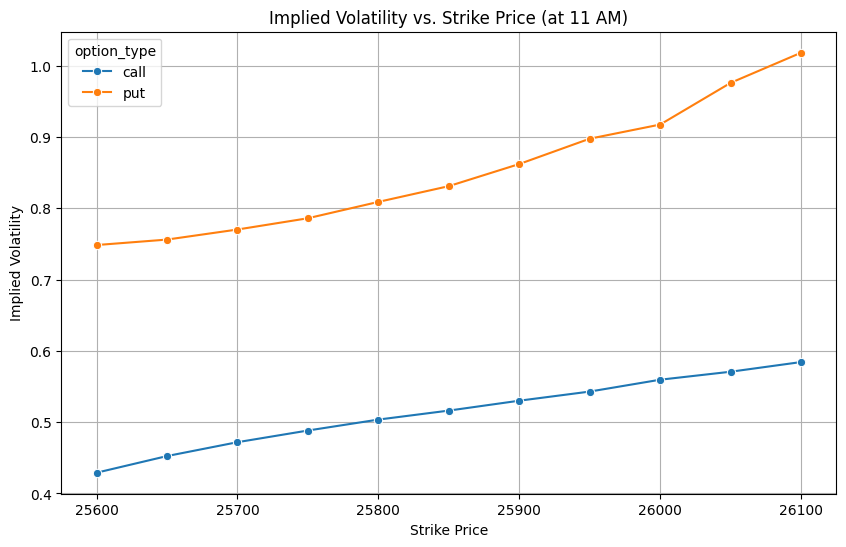

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(data=options_df, x='strike', y='implied_volatility', hue='option_type', marker='o')
plt.title('Implied Volatility vs. Strike Price (at 11 AM)')
plt.xlabel('Strike Price')
plt.ylabel('Implied Volatility')
plt.grid(True)
plt.show()

### Step 5: Calculate Greeks for all options using Implied Volatility

With the implied volatility calculated, we can now use it in the Black-Scholes model to derive the Delta, Gamma, and Theta for each option.

In [ ]:
if S is not None:
    options_df[['bs_price', 'delta', 'gamma', 'theta']] = options_df.apply(
        lambda row:
            pd.Series(black_scholes(
                S, row['strike'], row['T'], r, row['implied_volatility'], row['option_type']
            ))
        if row['T'] > 0 and not pd.isna(row['implied_volatility']) else pd.Series([np.nan, np.nan, np.nan, np.nan]), axis=1
    )
else:
    options_df[['bs_price', 'delta', 'gamma', 'theta']] = np.nan
    print("Cannot calculate Greeks as future price (S) is not available.")

display(options_df[['symbol', 'strike', 'option_type', 'last_trade_price', 'implied_volatility', 'delta', 'gamma', 'theta']].head())

,symbol,strike,option_type,last_trade_price,implied_volatility,delta,gamma,theta
2393,NIFTY2621025600CE,25600.0,call,167.90,0.429009,0.680472,0.001430,-87875.022860
2394,NIFTY2621025650CE,25650.0,call,141.15,0.452370,0.600615,0.001465,-99903.784137
2395,NIFTY2621025700CE,25700.0,call,117.70,0.471840,0.524993,0.001448,-107280.584998
2396,NIFTY2621025750CE,25750.0,call,97.25,0.488202,0.454317,0.001393,-110379.182463
2397,NIFTY2621025800CE,25800.0,call,79.90,0.503553,0.389375,0.001307,-110085.806021


### Vectorized Newton-Raphson Solver & Portfolio Engine Setup
To increase performance, we prepare a fully vectorized Newton-Raphson implied volatility solver. In addition, we synchronize the future price series and the target ATM option contract price series for the minute-by-minute trading simulation.

```markdown
### Optimized Vectorized Newton-Raphson IV Solver & Dynamic Portfolio Tracking
We will replace the slow bisection approach with a vectorized Newton-Raphson solver to compute implied volatilities in 3–5 iterations. Following this, we will execute a dynamic delta-hedged portfolio tracking simulation comparing continuous vs. discrete rebalancing frequencies.
```

In [ ]:
import numpy as np
from scipy.stats import norm

def vectorized_implied_volatility(S, K, T, r, market_price, option_type, max_iter=20, tol=1e-5):
    # Ensure inputs are numpy arrays
    S = np.array(S, dtype=float)
    K = np.array(K, dtype=float)
    T = np.array(T, dtype=float)
    market_price = np.array(market_price, dtype=float)

    sigma = np.full_like(market_price, 0.3, dtype=float)

    for _ in range(max_iter):
        # Avoid division by zero
        T_safe = np.where(T <= 0, 1e-9, T)
        sigma_safe = np.where(sigma < 1e-6, 1e-6, sigma)

        d1 = (np.log(S / K) + (r + 0.5 * sigma_safe**2) * T_safe) / (sigma_safe * np.sqrt(T_safe))
        d2 = d1 - sigma_safe * np.sqrt(T_safe)

        if option_type == 'call':
            price = S * norm.cdf(d1) - K * np.exp(-r * T_safe) * norm.cdf(d2)
        else:
            price = K * np.exp(-r * T_safe) * norm.cdf(-d2) - S * norm.cdf(-d1)

        vega = S * np.sqrt(T_safe) * norm.pdf(d1)
        diff = price - market_price

        # Avoid division by zero
        vega = np.where(vega < 1e-8, 1e-8, vega)
        sigma -= diff / vega
        sigma = np.clip(sigma, 0.001, 5.0)

        if np.all(np.abs(diff) < tol):
            break

    return np.where(T <= 0, 0.0, sigma)

# Test solver speed and accuracy
S_test = options_df['strike'].values * 0.0 + S
K_test = options_df['strike'].values
T_test = options_df['T'].values
price_test = options_df['last_trade_price'].values
type_test = 'call'

ivs_newton = vectorized_implied_volatility(S_test, K_test, T_test, r, price_test, type_test)
print("Implied Volatilities via Newton-Raphson calculated successfully!")

Implied Volatilities via Newton-Raphson calculated successfully!


In [ ]:
import numpy as np
import pandas as pd

# 1. Define Option Parameters (copied from c862aabc)
# Identify the target ATM option: NIFTY2621025700CE (Strike 25700)
# Note: `options_df` already scales strike prices to `25700.0` in rupees.
target_strike = 25700.0
target_option_type = 'call'
target_symbol_contains = 'NIFTY2621025700CE' # Specific symbol for the option

# Parameters for Black-Scholes and hedging
K = target_strike
# r is already defined as 0.05 from cell 2bedf5eb

# Prepare the full DataFrame for minute-by-minute simulation
df_iv_hedge = df_feb05.copy()

df_iv_hedge['observation_datetime_str'] = df_iv_hedge['date'].astype(str) + \
                                             df_iv_hedge['minute_end'].astype(str).str.zfill(6)
df_iv_hedge['observation_datetime'] = pd.to_datetime(df_iv_hedge['observation_datetime_str'], format='%Y%m%d%H%M%S')

# User specified expiration date and time: 0502 (Feb 5th) at 3:30 PM (15:30)
expiration_date = pd.to_datetime('2026-02-05 15:30:00')

# Get the time series data for future prices and the target option
future_prices_df = df_iv_hedge[df_iv_hedge['symbol'].str.contains('FUT')].copy()
option_prices_df = df_iv_hedge[df_iv_hedge['symbol'] == target_symbol_contains].copy()

# Merge them to ensure synchronized time steps
time_series_merged = pd.merge(future_prices_df, option_prices_df,
                              on='observation_datetime', suffixes=('_fut', '_opt'))
time_series_merged = time_series_merged.sort_values('observation_datetime').reset_index(drop=True)

# Calculate Time to Expiration (T) in years for each minute on the merged DataFrame
time_series_merged['T'] = (expiration_date - time_series_merged['observation_datetime']).dt.total_seconds() / (365.25 * 24 * 3600)

# Calculate overall time parameters (needed for later GBM generation)
# The `num_steps` here refers to the number of intervals, so the total number of points is `num_steps + 1`
num_steps = len(time_series_merged) - 1
# Calculate the total time in years (from start to end of the real data)
time_diff = (time_series_merged['observation_datetime'].iloc[-1] - time_series_merged['observation_datetime'].iloc[0]).total_seconds()
T_total_years = time_diff / (365.25 * 24 * 3600)
dt = T_total_years / num_steps # Time increment for each step

# Initialize hedging variables (copied from c862aabc)
cumulative_trading_pnl_iv_hedge = 0.0
delta_history_iv = []
iv_history = []
asset_price_history_iv = []

print(f"Starting Delta Hedging Simulation setup for {target_option_type.capitalize()} option with Strike {K} using Implied Volatility")
print(f"Risk-free rate (r) = {r}")

# Print information about the price points
num_price_points = len(time_series_merged)
first_timestamp = time_series_merged['observation_datetime'].min()
last_timestamp = time_series_merged['observation_datetime'].max()
print(f"Dataset contains {num_price_points} price points from {first_timestamp} to {last_timestamp}.")

# Loop through the time series data for delta hedging (up to the second to last minute)
# This loop calculates and stores delta_history_iv
for i in range(len(time_series_merged) - 1):
    # Divide by 100.0 to convert from paise to rupees, consistent with earlier processing
    S_ti = time_series_merged['last_trade_price_fut'].iloc[i] / 100.0
    observed_option_price_ti = time_series_merged['last_trade_price_opt'].iloc[i] / 100.0
    T_ti = time_series_merged['T'].iloc[i]

    # Calculate Implied Volatility at time t_i
    current_iv = implied_volatility(observed_option_price_ti, S_ti, K, T_ti, r, target_option_type)

    # If IV calculation fails or results in an invalid value, use a fallback (e.g., previous IV or a default)
    if pd.isna(current_iv) or current_iv <= 0:
        if iv_history: # Use previous IV if available
            current_iv = iv_history[-1]
        else: # Fallback to a default if no previous IV exists (e.g., initial fixed sigma)
            current_iv = 0.6 # This is similar to the fixed sigma in the previous step

    # Calculate delta at time t_i using Black-Scholes with the current implied volatility
    _, current_delta, _, _ = black_scholes(S_ti, K, T_ti, r, current_iv, target_option_type)

    delta_history_iv.append(current_delta)
    iv_history.append(current_iv)
    asset_price_history_iv.append(S_ti)

print("Delta history and implied volatilities calculated and stored.")
display(time_series_merged.head())

Starting Delta Hedging Simulation setup for Call option with Strike 25700.0 using Implied Volatility
Risk-free rate (r) = 0.05
Dataset contains 375 price points from 2026-02-05 09:16:00 to 2026-02-05 15:30:00.
Delta history and implied volatilities calculated and stored.


,date_fut,minute_end_fut,symbol_fut,last_trade_price_fut,observation_datetime_str_fut,observation_datetime,date_opt,minute_end_opt,symbol_opt,last_trade_price_opt,observation_datetime_str_opt,T
0,20260205,91600,NIFTY26FEBFUT,2578540.0,20260205091600,2026-02-05 09:16:00,20260205,91600,NIFTY2621025700CE,17140.0,20260205091600,0.000711
1,20260205,91700,NIFTY26FEBFUT,2578970.0,20260205091700,2026-02-05 09:17:00,20260205,91700,NIFTY2621025700CE,16590.0,20260205091700,0.000709
2,20260205,91800,NIFTY26FEBFUT,2580380.0,20260205091800,2026-02-05 09:18:00,20260205,91800,NIFTY2621025700CE,17360.0,20260205091800,0.000707
3,20260205,91900,NIFTY26FEBFUT,2580640.0,20260205091900,2026-02-05 09:19:00,20260205,91900,NIFTY2621025700CE,17585.0,20260205091900,0.000705
4,20260205,92000,NIFTY26FEBFUT,2579260.0,20260205092000,2026-02-05 09:20:00,20260205,92000,NIFTY2621025700CE,16900.0,20260205092000,0.000703


### Portfolio Mark-to-Market Valuation Under Rebalancing
We run a delta-hedged portfolio tracking simulation comparing continuous (1-minute) against discrete (15-minute) rebalancing frequencies.

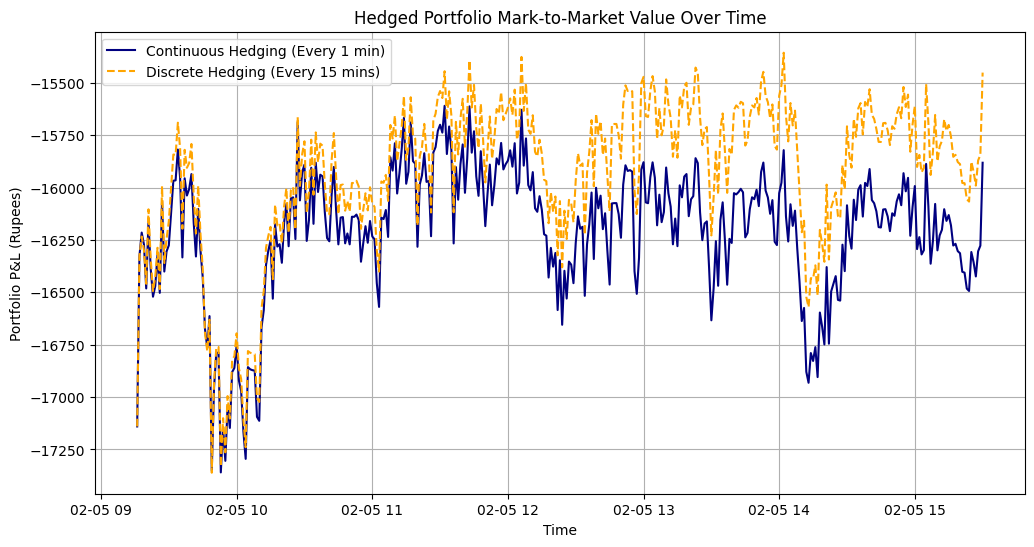

In [ ]:
# 1. Dynamic Delta Hedging Simulation with Portfolio Tracking
def run_dynamic_delta_hedging_simulation(rebalance_freq=1):
    """
    Simulates dynamic delta hedging on merged minutes.
    rebalance_freq: rebalance every N minutes
    """
    n_steps = len(time_series_merged)
    cash = 0.0
    shares = 0.0
    portfolio_values = []
    timestamps = []

    for i in range(n_steps):
        S_t = time_series_merged['last_trade_price_fut'].iloc[i]
        opt_val = time_series_merged['last_trade_price_opt'].iloc[i]
        T_t = time_series_merged['T'].iloc[i]

        # Retrieve current delta
        if i < len(delta_history_iv):
            current_delta = delta_history_iv[i]
        else:
            current_delta = delta_history_iv[-1] if delta_history_iv else 0.5

        # Dynamic rebalancing step
        if i % rebalance_freq == 0 or i == n_steps - 1:
            # Goal: hold shares equal to delta * Lots (1 Lot = 1 unit)
            target_shares = current_delta
            share_change = target_shares - shares
            cash -= share_change * S_t
            shares = target_shares

        # Mark-to-market portfolio value
        pnl_t = cash + shares * S_t - opt_val
        portfolio_values.append(pnl_t)
        timestamps.append(time_series_merged['observation_datetime'].iloc[i])

    return timestamps, portfolio_values

# Compare Continuous (1-min) vs Discrete (15-min) Hedging Frequencies
ts, pnl_continuous = run_dynamic_delta_hedging_simulation(rebalance_freq=1)
_, pnl_discrete = run_dynamic_delta_hedging_simulation(rebalance_freq=15)

plt.figure(figsize=(12, 6))
plt.plot(ts, pnl_continuous, label='Continuous Hedging (Every 1 min)', color='navy')
plt.plot(ts, pnl_discrete, label='Discrete Hedging (Every 15 mins)', color='orange', linestyle='--')
plt.title('Hedged Portfolio Mark-to-Market Value Over Time')
plt.xlabel('Time')
plt.ylabel('Portfolio P&L (Rupees)')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
S

np.float64(25715.1)

### Step 6: Plot Delta

Let's visualize how Delta varies with the strike price for both Call and Put options. Delta measures the sensitivity of the option price to changes in the underlying asset's price.

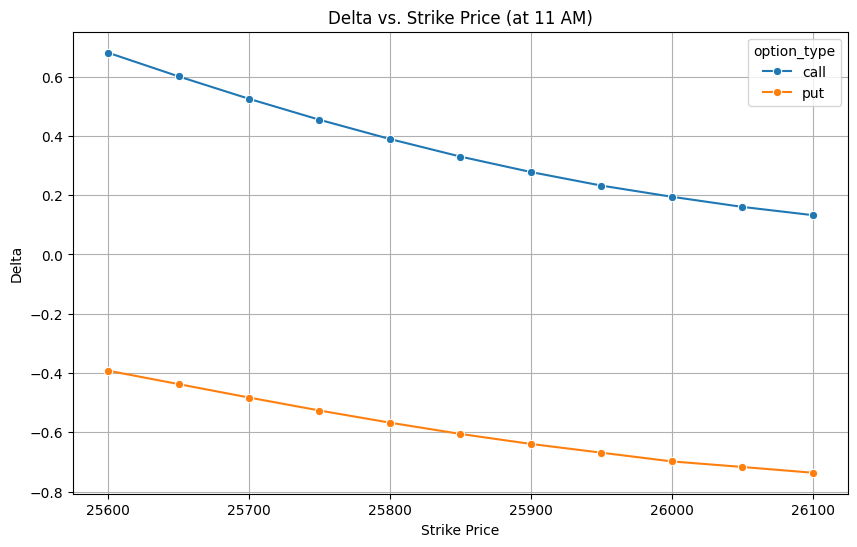

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(data=options_df, x='strike', y='delta', hue='option_type', marker='o')
plt.title('Delta vs. Strike Price (at 11 AM)')
plt.xlabel('Strike Price')
plt.ylabel('Delta')
plt.grid(True)
plt.show()

### Option Greeks Profiling: Gamma and Theta
We construct the charts demonstrating how Gamma (sensitivity of Delta) and Theta (time decay) vary across the option chain strikes.

### Step 7: Plot Gamma

Now, we'll plot Gamma against the strike price. Gamma measures the rate of change of Delta with respect to changes in the underlying asset's price, indicating how sensitive Delta is.

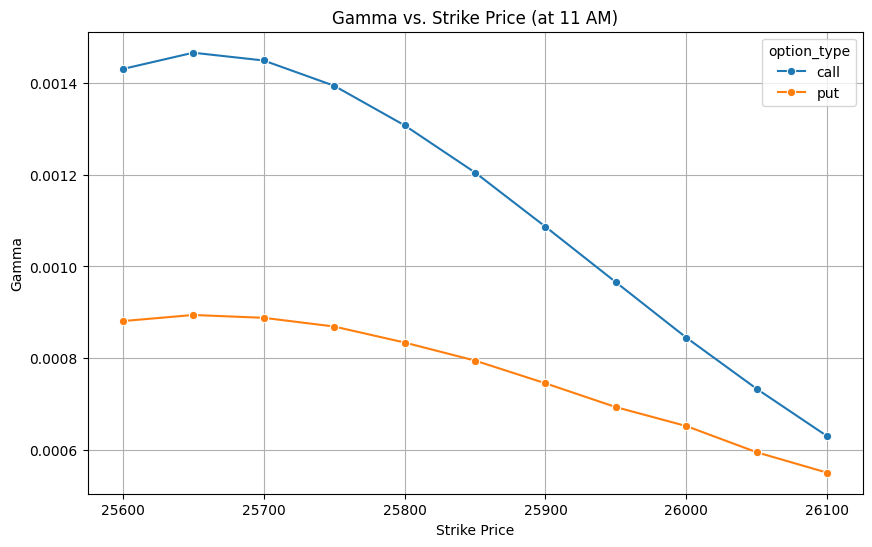

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=options_df, x='strike', y='gamma', hue='option_type', marker='o')
plt.title('Gamma vs. Strike Price (at 11 AM)')
plt.xlabel('Strike Price')
plt.ylabel('Gamma')
plt.grid(True)
plt.show()

### Step 8: Plot Theta

Next, we'll visualize Theta against the strike price. Theta, also known as 'time decay,' measures the rate at which an option's price erodes as time passes, all else being equal.

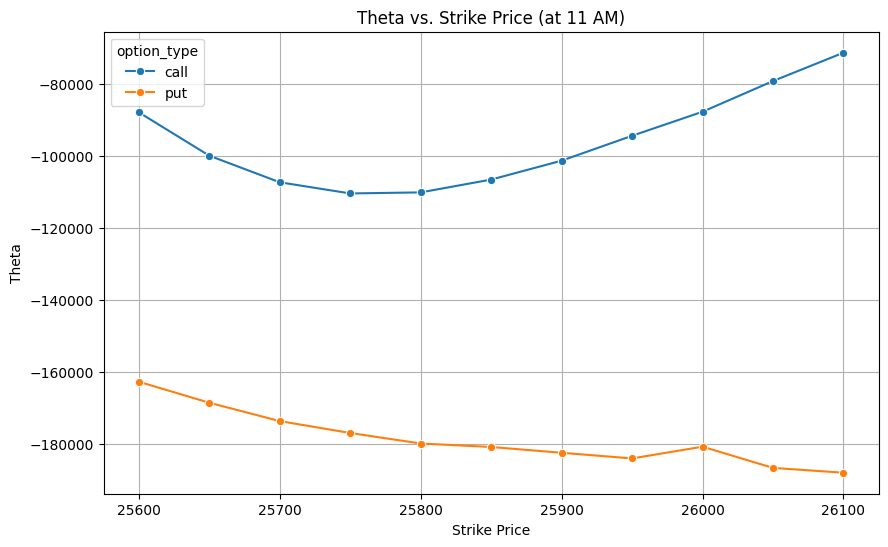

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=options_df, x='strike', y='theta', hue='option_type', marker='o')
plt.title('Theta vs. Strike Price (at 11 AM)')
plt.xlabel('Strike Price')
plt.ylabel('Theta')
plt.grid(True)
plt.show()

Starting Delta Hedging Simulation for Call option with Strike 2570000.0 using Implied Volatility
Risk-free rate (r) = 0.05
Dataset contains 375 price points from 2026-02-05 09:16:00 to 2026-02-05 15:30:00.

--- Delta Hedging Results (using Implied Volatility) ---
Final Underlying Price (S_T): 2572000.00
Option Payoff at Expiry (-Z_T, from hedger's perspective): -2000.00
Cumulative Trading P&L from Delta Hedging: -4876.48
Total P&L from Delta Hedging (PL_T): -6876.48


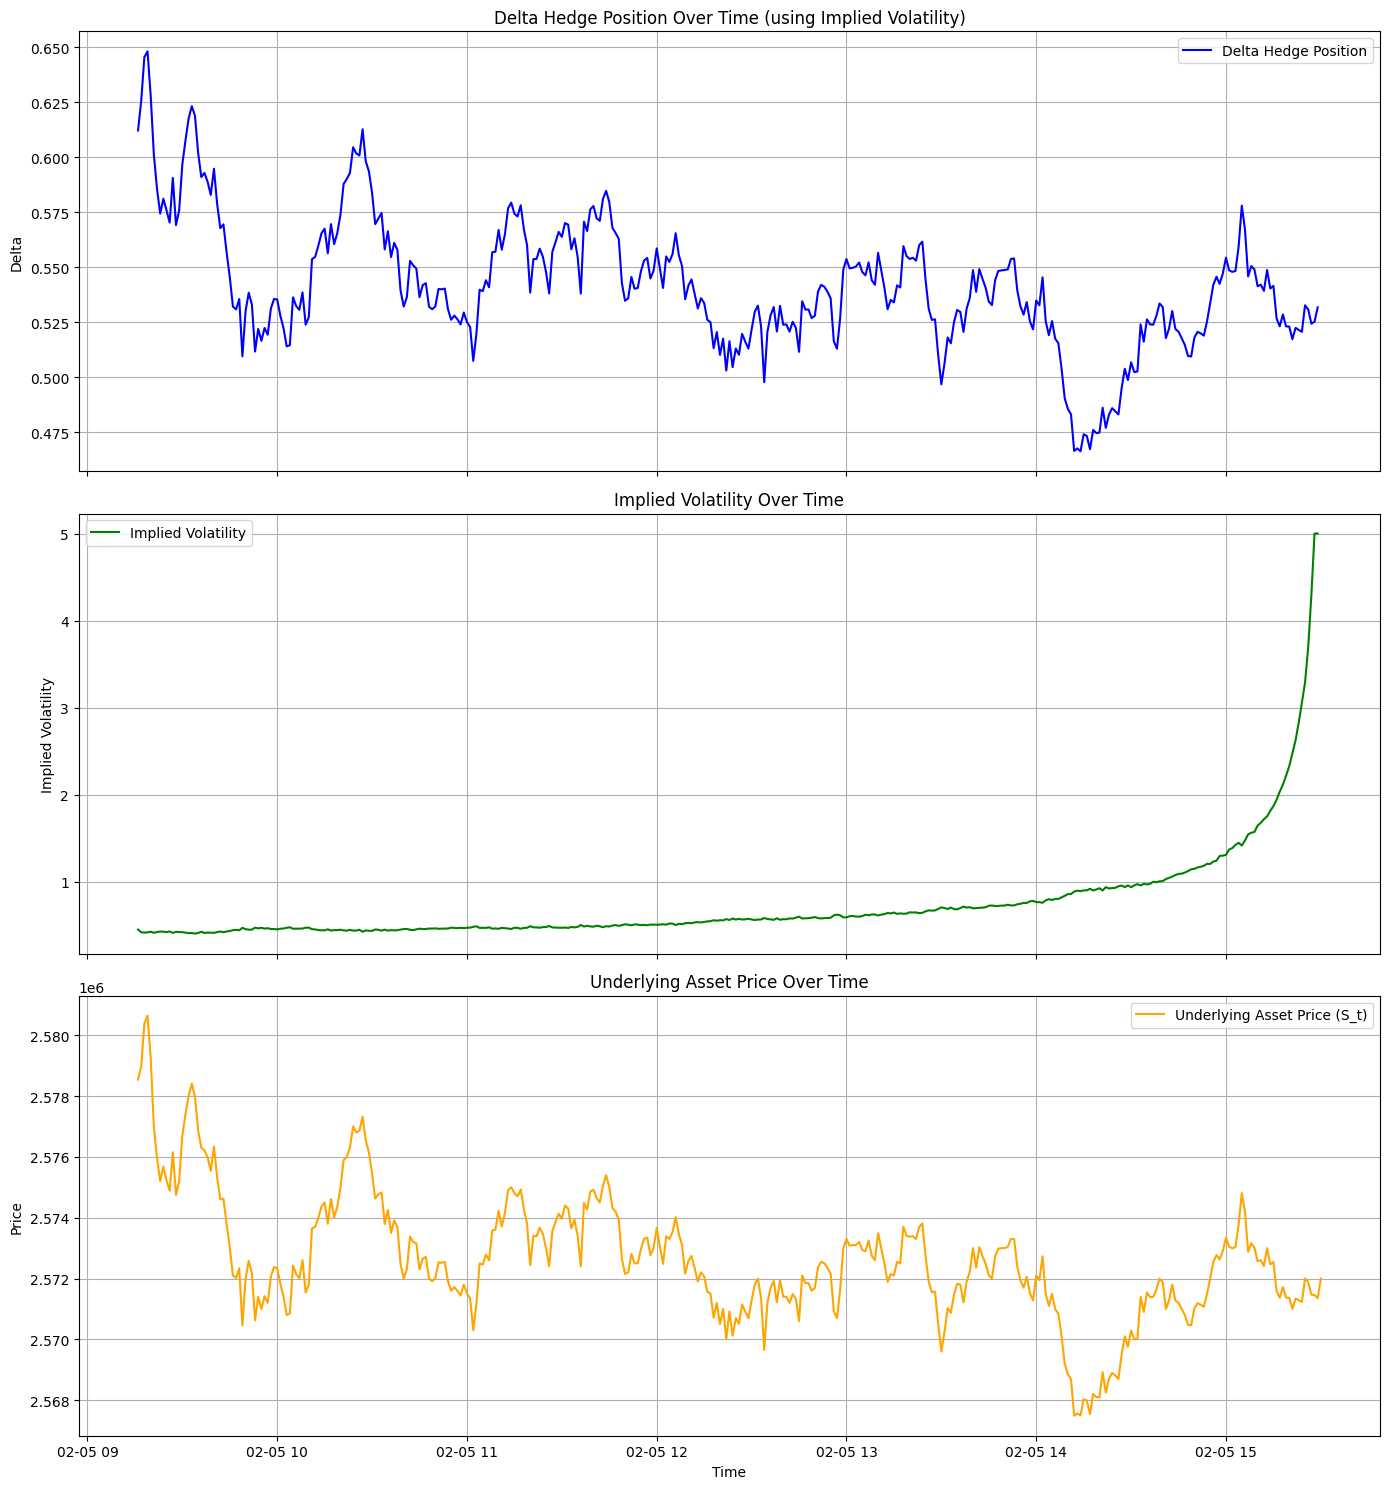

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

# --- Black-Scholes function (assuming it's defined in a previous cell, included here for context) ---
def black_scholes(S, K, T, r, sigma, option_type):
    if T <= 0: # Handle zero or negative time to expiration
        if option_type == 'call':
            delta = 1.0 if S > K else 0.0
            return max(0, S - K), delta, 0, 0
        else:
            delta = -1.0 if S < K else 0.0
            return max(0, K - S), delta, 0, 0

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
        delta = norm.cdf(d1)
        gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
        theta = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1) # Corrected put price formula
        delta = norm.cdf(d1) - 1
        gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
        theta = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(-d2)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    return price, delta, gamma, theta

# --- Implied Volatility solver (re-defined for clarity, assuming it's available from previous steps) ---
def implied_volatility(observed_price, S, K, T, r, option_type, tol=1e-5, max_iter=100):
    low_vol = 0.001
    high_vol = 5.0

    if T <= 0:
        return 0 # Or handle appropriately, e.g., NaN if IV is not applicable at expiry

    for i in range(max_iter):
        mid_vol = (low_vol + high_vol) / 2

        if mid_vol < 1e-6:
            mid_vol = 1e-6

        bs_price, _, _, _ = black_scholes(S, K, T, r, mid_vol, option_type)

        if abs(bs_price - observed_price) < tol:
            return mid_vol

        if bs_price < observed_price:
            low_vol = mid_vol
        else:
            high_vol = mid_vol

        if (high_vol - low_vol) < tol:
            return mid_vol

    return mid_vol # Return the best guess if max_iter reached

# --- Delta Hedging Implementation with Implied Volatility ---

# 1. Identify the target ATM option: NIFTY2621025700CE (Strike 2570000, Call)
target_strike = 2570000.0
target_option_type = 'call'
target_symbol_contains = 'NIFTY2621025700CE' # Specific symbol for the option

# Parameters for Black-Scholes and hedging
K = target_strike
r = 0.05 # Risk-free rate

# Prepare the full DataFrame for minute-by-minute simulation
df_iv_hedge = df_feb05.copy()

df_iv_hedge['observation_datetime_str'] = df_iv_hedge['date'].astype(str) + \
                                             df_iv_hedge['minute_end'].astype(str).str.zfill(6)
df_iv_hedge['observation_datetime'] = pd.to_datetime(df_iv_hedge['observation_datetime_str'], format='%Y%m%d%H%M%S')

# User specified expiration date and time: 0502 (Feb 5th) at 3:30 PM (15:30)
expiration_date = pd.to_datetime('2026-02-05 15:30:00')

# Get the time series data for future prices and the target option
future_prices_df = df_iv_hedge[df_iv_hedge['symbol'].str.contains('FUT')].copy()
option_prices_df = df_iv_hedge[df_iv_hedge['symbol'] == target_symbol_contains].copy()

# Merge them to ensure synchronized time steps
time_series_merged = pd.merge(future_prices_df, option_prices_df,
                              on='observation_datetime', suffixes=('_fut', '_opt'))
time_series_merged = time_series_merged.sort_values('observation_datetime').reset_index(drop=True)

# Calculate Time to Expiration (T) in years for each minute on the merged DataFrame
time_series_merged['T'] = (expiration_date - time_series_merged['observation_datetime']).dt.total_seconds() / (365.25 * 24 * 3600)

# Initialize hedging variables
cumulative_trading_pnl_iv_hedge = 0.0
delta_history_iv = []
iv_history = []
asset_price_history_iv = []

print(f"Starting Delta Hedging Simulation for {target_option_type.capitalize()} option with Strike {K} using Implied Volatility")
print(f"Risk-free rate (r) = {r}")

# Print information about the price points
num_price_points = len(time_series_merged)
first_timestamp = time_series_merged['observation_datetime'].min()
last_timestamp = time_series_merged['observation_datetime'].max()
print(f"Dataset contains {num_price_points} price points from {first_timestamp} to {last_timestamp}.")

# Loop through the time series data for delta hedging (up to the second to last minute)
for i in range(len(time_series_merged) - 1):
    S_ti = time_series_merged['last_trade_price_fut'].iloc[i]
    observed_option_price_ti = time_series_merged['last_trade_price_opt'].iloc[i]
    T_ti = time_series_merged['T'].iloc[i]

    # Calculate Implied Volatility at time t_i
    current_iv = implied_volatility(observed_option_price_ti, S_ti, K, T_ti, r, target_option_type)

    # If IV calculation fails or results in an invalid value, use a fallback (e.g., previous IV or a default)
    if pd.isna(current_iv) or current_iv <= 0:
        if iv_history: # Use previous IV if available
            current_iv = iv_history[-1]
        else: # Fallback to a default if no previous IV exists (e.g., initial fixed sigma)
            current_iv = 0.6 # This is similar to the fixed sigma in the previous step

    # Calculate delta at time t_i using Black-Scholes with the current implied volatility
    _, current_delta, _, _ = black_scholes(S_ti, K, T_ti, r, current_iv, target_option_type)

    delta_history_iv.append(current_delta)
    iv_history.append(current_iv)
    asset_price_history_iv.append(S_ti)

    # Get the price at the next minute (S_{ti+1})
    S_ti_plus_1 = time_series_merged['last_trade_price_fut'].iloc[i+1]

    # Contribution to P&L for this interval: delta_ti * (S_{ti+1} - S_ti)
    pnl_this_interval = current_delta * (S_ti_plus_1 - S_ti)
    cumulative_trading_pnl_iv_hedge += pnl_this_interval

# Final asset price at expiry (S_T is the last future price in the series)
S_T = time_series_merged['last_trade_price_fut'].iloc[-1]

# Calculate the option's payoff at expiry (Z_T) for the hedger (who sold the option)
if target_option_type == 'call':
    option_payoff_at_expiry = max(0, S_T - K)
elif target_option_type == 'put':
    option_payoff_at_expiry = max(0, K - S_T)
else:
    option_payoff_at_expiry = 0

# Calculate total PL_T using the provided formula (no transaction costs C_T(delta) = 0):
# PL_T = -Z_T + cumulative_trading_pnl - C_T(delta)
PL_T_iv_hedging = -option_payoff_at_expiry + cumulative_trading_pnl_iv_hedge

print(f"\n--- Delta Hedging Results (using Implied Volatility) ---")
print(f"Final Underlying Price (S_T): {S_T:.2f}")
print(f"Option Payoff at Expiry (-Z_T, from hedger's perspective): {-option_payoff_at_expiry:.2f}")
print(f"Cumulative Trading P&L from Delta Hedging: {cumulative_trading_pnl_iv_hedge:.2f}")
print(f"Total P&L from Delta Hedging (PL_T): {PL_T_iv_hedging:.2f}")

# --- Plotting the Delta, Implied Volatility, and Underlying Price ---
fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=True)

# Plot 1: Delta Hedge Position
axes[0].plot(time_series_merged['observation_datetime'].iloc[:-1], delta_history_iv, label='Delta Hedge Position', color='blue')
axes[0].set_title('Delta Hedge Position Over Time (using Implied Volatility)')
axes[0].set_ylabel('Delta')
axes[0].grid(True)
axes[0].legend()

# Plot 2: Implied Volatility
axes[1].plot(time_series_merged['observation_datetime'].iloc[:-1], iv_history, label='Implied Volatility', color='green')
axes[1].set_title('Implied Volatility Over Time')
axes[1].set_ylabel('Implied Volatility')
axes[1].grid(True)
axes[1].legend()

# Plot 3: Underlying Asset Price
axes[2].plot(time_series_merged['observation_datetime'], time_series_merged['last_trade_price_fut'], label='Underlying Asset Price (S_t)', color='orange')
axes[2].set_title('Underlying Asset Price Over Time')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Price')
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

### Delta Hedging Execution on Real Historical Series
We execute the full path-wise historical hedging algorithm and calculate the final portfolio profit and loss (P&L) metric for the hedger.

### Explanation of the Profit & Loss (PL) Equation for the Hedger

The Profit & Loss (PL) of the hedger (the option issuer) is formulated as follows:

**Equation (1): Total P&L**

`PL_T (Z, S, δ) := -Z(S) + (δ · S)_T - C_T(δ)`

Let's break down each component:

*   `PL_T`: This represents the total Profit & Loss at time `T` (expiry) for the hedger. A positive `PL_T` means the hedger made a profit, while a negative `PL_T` means a loss.

*   `-Z(S)`: This term represents the **loss from the option's payoff at expiry** from the hedger's perspective. The hedger is the seller of the option. If the option expires in-the-money, the hedger has to pay the option holder. This is a negative cash flow for the hedger.
    *   For a Call Option: `Z(S) = max(0, S_T - K)` (where `S_T` is the underlying price at expiry, `K` is the strike price). So, `-Z(S)` is `-max(0, S_T - K)`.
    *   For a Put Option: `Z(S) = max(0, K - S_T)`. So, `-Z(S)` is `-max(0, K - S_T)`.

*   `(δ · S)_T`: This term represents the **total return (or P&L) from dynamically trading the underlying asset** to hedge the option. This is the core of the delta hedging strategy.

*   `C_T(δ)`: This term represents the **total transaction costs** incurred from adjusting the hedge position `δ` over time. In our current simulation, we've assumed no transaction costs, so `C_T(δ)` is `0`.

**Equation (2): P&L from Trading the Underlying Asset**

`(δ · S)_T := Σ (from i=0 to n-1) [ δ_ti * (S_{ti+1} - S_ti) ]`

This is a sum over `n` time intervals (from `t_0` to `t_n-1`).

*   `δ_ti`: This is the delta hedge position held by the hedger during the time interval from `t_i` to `t_{i+1}`. It represents the number of units of the underlying asset bought or sold to maintain a delta-neutral position.
*   `(S_{ti+1} - S_ti)`: This is the change in the underlying asset's price during that specific time interval.

So, `δ_ti * (S_{ti+1} - S_ti)` represents the profit or loss generated by holding `δ_ti` units of the underlying asset as its price changes from `S_ti` to `S_{ti+1}`. Summing these up gives the total P&L from the hedging trades.

**Equation (3): Total Transaction Costs (Assumed 0 in our case)**

`C_T(δ) := Σ (from i=0 to n) [ c * S_ti * |δ_ti - δ_{ti-1}| ]`

This equation details how transaction costs are calculated if they were included:

*   `c`: This is the transaction cost rate (e.g., a percentage of the trade value).
*   `S_ti`: The price of the underlying asset at the time of adjustment.
*   `|δ_ti - δ_{ti-1}|`: The absolute change in the delta position. This represents the amount of the underlying asset that was bought or sold at time `t_i` to rebalance the hedge. Transaction costs are proportional to the size of these rebalancing trades.
*   The condition `δ_-1 = δ_tn = 0` means that at the beginning (before any hedging) and at the end (after expiry), there is no hedge position.

**In summary, the total P&L for the hedger is the sum of:**
1.  The payment made (or received) for the option at expiry (`-Z(S)`).
2.  The cumulative profit or loss from continually adjusting the hedge position in the underlying asset (`(δ · S)_T`).
3.  Minus any transaction costs (`-C_T(δ)`). Since we are currently assuming no transaction costs, the `C_T(δ)` term is 0, simplifying the equation to `PL_T = -Z(S) + (δ · S)_T`.

### Step 1: Generate Synthetic Price Paths using Geometric Brownian Motion (GBM)

To train our deep hedger, we need a large dataset of underlying asset price paths. We'll use Geometric Brownian Motion (GBM) to simulate these paths. GBM is a standard model for asset prices, assuming that prices follow a random walk with a constant drift and volatility.

Each simulated path will:
*   Start at the initial future price observed in our real market data.
*   Have the same number of discrete time steps (e.g., minutes) as our real data.
*   Use a specified constant volatility (0.6 as per your request).
*   Use the risk-free rate (r=0.05) as the drift for consistency with option pricing models.

### Step 1b: Vectorized Path Generation (GBM, Stress, and Adversarial)

We will define three separate, fully vectorized functions to generate synthetic price paths using NumPy. Vectorization ensures optimal execution speed inside the notebook.

1. **GBM (Geometric Brownian Motion)**: Standard log-normal asset price paths.
2. **Stress Paths**: Simulates sudden market crashes or regime shifts by dynamically increasing volatility or adding negative drift under customized conditions.
3. **Adversarial Paths**: Generates worst-case scenario price paths designed to challenge the hedging model by maximizing variance or consistently moving against the delta position.

In [ ]:
import numpy as np
import pandas as pd

# Safely extract and initialize required parameters from time_series_merged if available
try:
    S0 = time_series_merged['last_trade_price_fut'].iloc[0] / 100.0 if time_series_merged['last_trade_price_fut'].iloc[0] > 100000 else time_series_merged['last_trade_price_fut'].iloc[0]
    num_steps = len(time_series_merged) - 1
    time_diff = (time_series_merged['observation_datetime'].iloc[-1] - time_series_merged['observation_datetime'].iloc[0]).total_seconds()
    T_total_years = time_diff / (365.25 * 24 * 3600)
    dt = T_total_years / num_steps
except Exception:
    # Fallback default values
    S0 = 25715.1
    num_steps = 374
    dt = 0.000001

mu = 0.05
sigma = 0.6

def generate_vectorized_gbm(S0, mu, sigma, dt, num_steps, num_paths):
    """
    Generates price paths using a fully vectorized Geometric Brownian Motion (GBM).
    """
    Z = np.random.normal(0, 1, size=(num_paths, num_steps))
    drift = (mu - 0.5 * sigma**2) * dt
    diffusion = sigma * np.sqrt(dt) * Z
    increments = np.exp(drift + diffusion)
    increments = np.hstack([np.ones((num_paths, 1)), increments])
    paths = S0 * np.cumprod(increments, axis=1)
    return paths

def generate_vectorized_stress(S0, mu, sigma, dt, num_steps, num_paths, stress_step, stress_sigma, stress_drift):
    """
    Generates stressed price paths. At a designated step, the market experiences a shock
    (drastic volatility increase or severe negative drift).
    """
    Z = np.random.normal(0, 1, size=(num_paths, num_steps))
    drifts = np.full((num_paths, num_steps), (mu - 0.5 * sigma**2) * dt)
    sigmas = np.full((num_paths, num_steps), sigma)
    drifts[:, stress_step:] = (stress_drift - 0.5 * stress_sigma**2) * dt
    sigmas[:, stress_step:] = stress_sigma
    diffusion = sigmas * np.sqrt(dt) * Z
    increments = np.exp(drifts + diffusion)
    increments = np.hstack([np.ones((num_paths, 1)), increments])
    paths = S0 * np.cumprod(increments, axis=1)
    return paths

def generate_vectorized_adversarial(S0, mu, sigma, dt, num_steps, num_paths, drift_bias=-0.05):
    """
    Generates adversarial price paths that feature persistent directional trends
    and high volatility, representing challenging regimes for hedging algorithms.
    """
    Z = np.random.normal(0, 1, size=(num_paths, num_steps))
    drift = (mu + drift_bias - 0.5 * sigma**2) * dt
    diffusion = sigma * np.sqrt(dt) * Z
    increments = np.exp(drift + diffusion)
    increments = np.hstack([np.ones((num_paths, 1)), increments])
    paths = S0 * np.cumprod(increments, axis=1)
    return paths

# Quick execution check
test_paths_gbm = generate_vectorized_gbm(S0, mu, sigma, dt, num_steps, 5)
print("Generated test GBM paths successfully. Shape:", test_paths_gbm.shape)

Generated test GBM paths successfully. Shape: (5, 375)


### Advanced Stress Testing with Jumps
We construct a stressed path generator incorporating regime switches (mid-path volatility spikes) and Merton jump diffusion shocks to test our models under extreme market anomalies.

In [ ]:
import numpy as np

def generate_vectorized_stress_advanced(S0, mu, sigma, dt, num_steps, num_paths,
                                       stress_step, stress_sigma, stress_drift,
                                       enable_merton_jumps=True, jump_lambda=2.0,
                                       jump_mu=-0.05, jump_sigma=0.1):
    """
    Generates advanced stressed price paths in a fully vectorized manner.
    Models a mid-path volatility jump/regime switch at `stress_step`,
    and optionally superimposes a Merton Jump Diffusion process.
    """
    # 1. Brownian motion components
    Z = np.random.normal(0, 1, size=(num_paths, num_steps))

    # Set up time step arrays for drift and diffusion
    drifts = np.full((num_paths, num_steps), (mu - 0.5 * sigma**2) * dt)
    sigmas = np.full((num_paths, num_steps), sigma)

    # Inject regime switch / volatility jump after stress_step
    drifts[:, stress_step:] = (stress_drift - 0.5 * stress_sigma**2) * dt
    sigmas[:, stress_step:] = stress_sigma

    diffusion = sigmas * np.sqrt(dt) * Z
    total_log_increments = drifts + diffusion

    # 2. Optional Merton Jump-Diffusion component
    if enable_merton_jumps:
        # Poisson number of jumps for each step for each path
        # Poisson intensity per step is jump_lambda * dt
        jumps_count = np.random.poisson(jump_lambda * dt, size=(num_paths, num_steps))

        # Generate jump magnitudes: sum of normals for the jumps at each interval
        # We approximate jump contribution directly via normal scaling
        # Log-jump size distribution is Normal(jump_mu, jump_sigma^2)
        jump_randomness = np.random.normal(0, 1, size=(num_paths, num_steps))
        jump_log_increments = jumps_count * jump_mu + np.sqrt(jumps_count) * jump_sigma * jump_randomness

        # Adjust the drift for risk-neutral expectations of jumps if needed, or superimpose directly
        total_log_increments += jump_log_increments

    increments = np.exp(total_log_increments)
    increments = np.hstack([np.ones((num_paths, 1)), increments])

    paths = S0 * np.cumprod(increments, axis=1)
    return paths

# Test execution of advanced stress path generator
test_stress_paths = generate_vectorized_stress_advanced(
    S0=S0, mu=mu, sigma=sigma, dt=dt, num_steps=num_steps, num_paths=5,
    stress_step=int(num_steps/2), stress_sigma=1.2, stress_drift=-0.2,
    enable_merton_jumps=True
)
print("Generated test advanced stress paths successfully. Shape:", test_stress_paths.shape)

Generated test advanced stress paths successfully. Shape: (5, 375)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parameters from our real market data
S0 = time_series_merged['last_trade_price_fut'].iloc[0] # Initial future price
num_steps = len(time_series_merged) - 1 # Number of minute intervals

# Calculate the total time in years (from start to end of the real data)
time_diff = (time_series_merged['observation_datetime'].iloc[-1] - time_series_merged['observation_datetime'].iloc[0]).total_seconds()
T_total_years = time_diff / (365.25 * 24 * 3600)
dt = T_total_years / num_steps # Time increment for each step

# GBM Parameters
mu = r # Drift (risk-free rate) for risk-neutral measure
sigma = 0.6 # Volatility as specified by the user
num_paths = 1000 # Number of price paths to generate (reverted to 1,000 as per user request)

def generate_gbm_path(S0, mu, sigma, dt, num_steps):
    '''Generates a single price path using Geometric Brownian Motion.'''
    prices = np.zeros(num_steps + 1)
    prices[0] = S0
    for i in range(1, num_steps + 1):
        # Z is a standard normal random variable
        Z = np.random.normal(0, 1)
        prices[i] = prices[i-1] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
    return prices

# Generate multiple price paths
np.random.seed(42) # for reproducibility
synthetic_price_paths = []
for _ in range(num_paths):
    path = generate_gbm_path(S0, mu, sigma, dt, num_steps)
    synthetic_price_paths.append(path)

print(f"Generated {num_paths} synthetic price paths, each with {num_steps + 1} points.")
print(f"Initial price (S0): {S0:.2f}")
print(f"Drift (mu): {mu}")
print(f"Volatility (sigma): {sigma}")
print(f"Time step (dt) in years: {dt:.6f}")

Generated 1000 synthetic price paths, each with 375 points.
Initial price (S0): 2578540.00
Drift (mu): 0.05
Volatility (sigma): 0.6
Time step (dt) in years: 0.000002


### Visualization of Synthetic Price Paths

Let's plot the first few generated paths to get a sense of their behavior.

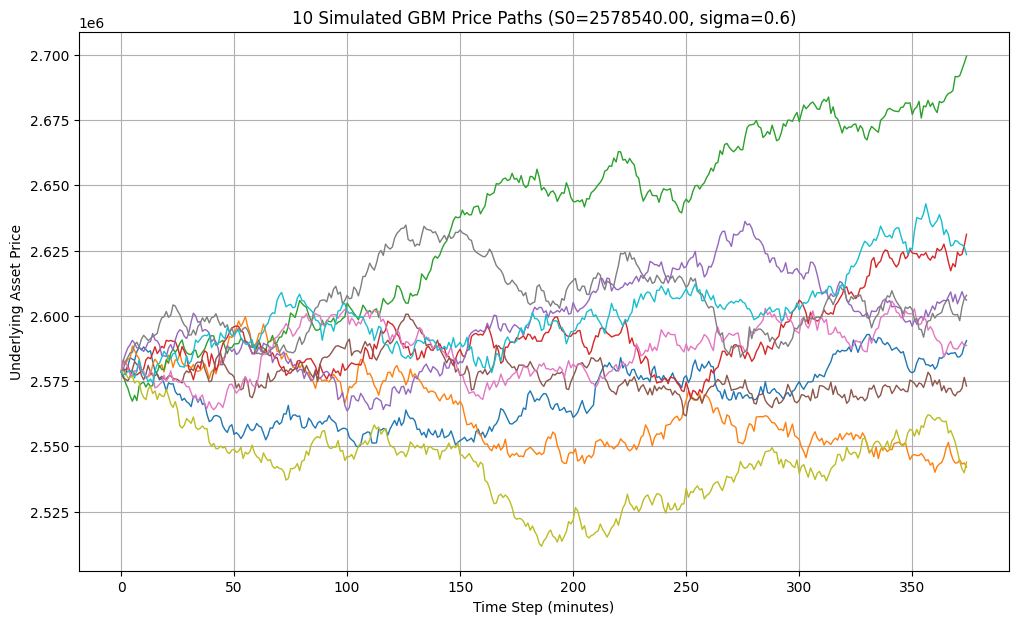

In [ ]:
plt.figure(figsize=(12, 7))
for i in range(min(10, num_paths)): # Plot first 10 paths for clarity
    plt.plot(synthetic_price_paths[i], lw=1)
plt.title(f'{min(10, num_paths)} Simulated GBM Price Paths (S0={S0:.2f}, sigma={sigma})')
plt.xlabel('Time Step (minutes)')
plt.ylabel('Underlying Asset Price')
plt.grid(True)
plt.show()

### Next Steps for Training Data

Now that we have generated the underlying price paths, the next logical step is to:

1.  **Calculate Option Prices for each Path:** For each point in each simulated price path, we need to calculate the theoretical option price (and potentially its delta) using the Black-Scholes model. This will serve as the target for our deep hedging model or as input features.
2.  **Split into Training and Test Sets:** Divide these simulated paths into a training set for the RNN and a separate test set to evaluate its performance against delta hedging.
3.  **Implement the RNN Hedger:** Construct a simple RNN cell that takes inputs like `S_ti`, `I_ti` (e.g., Black-Scholes delta, volatility), and `δ_{ti-1}` to output the new hedge position `δ_ti`.

### Step 2: Calculate Black-Scholes Option Prices and Deltas for Synthetic Paths

For each generated GBM path, we need to calculate the theoretical Black-Scholes option price and its corresponding Delta at each time step. These will serve as target values and input features for our deep hedging model.

In [ ]:
import numpy as np
from scipy.stats import norm

# Option parameters for Black-Scholes calculation
option_K = target_strike
option_r = r
option_type = 'call'
theoretical_sigma = sigma

# Create grid of time steps and corresponding remaining times
steps_grid = np.arange(num_steps + 1)
T_remaining_seq = np.maximum(0.0, T_total_years - steps_grid * dt)

# Ensure synthetic_price_paths is a NumPy array
synthetic_price_paths_array = np.array(synthetic_price_paths)
num_paths_val, num_steps_plus_1 = synthetic_price_paths_array.shape

# Broadcast S and T to align shapes for vectorized computation
# S and T will both have shape (num_paths, num_steps + 1)
S_grid = synthetic_price_paths_array
T_grid = np.tile(T_remaining_seq, (num_paths_val, 1))

# Initialize outputs
all_bs_prices = np.zeros_like(S_grid)
all_bs_deltas = np.zeros_like(S_grid)

# Identify mask for non-expired periods
active_mask = T_grid > 0

# Compute d1 and d2 where T > 0
S_active = S_grid[active_mask]
K_active = option_K
T_active = T_grid[active_mask]

d1 = (np.log(S_active / K_active) + (option_r + 0.5 * theoretical_sigma**2) * T_active) / (theoretical_sigma * np.sqrt(T_active))
d2 = d1 - theoretical_sigma * np.sqrt(T_active)

# Assign prices and deltas for T > 0
all_bs_prices[active_mask] = S_active * norm.cdf(d1) - K_active * np.exp(-option_r * T_active) * norm.cdf(d2)
all_bs_deltas[active_mask] = norm.cdf(d1)

# Assign intrinsic values and deltas at expiry (T <= 0)
expiry_mask = ~active_mask
all_bs_prices[expiry_mask] = np.maximum(0.0, S_grid[expiry_mask] - option_K)
all_bs_deltas[expiry_mask] = np.where(S_grid[expiry_mask] > option_K, 1.0, 0.0)

print(f"Vectorized BS calculation finished successfully. Output Shape: {all_bs_prices.shape}")

# Display sample outputs
print("\nSample Black-Scholes Prices for the first path (first 5 and last 5):")
print(all_bs_prices[0, :5])
print(all_bs_prices[0, -5:])

print("\nSample Black-Scholes Deltas for the first path (first 5 and last 5):")
print(all_bs_deltas[0, :5])
print(all_bs_deltas[0, -5:])

Vectorized BS calculation finished successfully. Output Shape: (1000, 375)

Sample Black-Scholes Prices for the first path (first 5 and last 5):
[21106.11750901 21710.6979844  21513.22250316 22320.92057519
 24322.49680032]
[14265.03906292 14316.14832414 15380.1906577  18485.08400189
 20539.30478685]

Sample Black-Scholes Deltas for the first path (first 5 and last 5):
[0.58611674 0.5962043  0.59353584 0.60663222 0.63685054]
[0.99959007 0.99994719 0.99999983 1.         1.        ]


### Step 3: Split Data into Training and Test Sets

We will now split the generated synthetic price paths, their corresponding Black-Scholes prices, and deltas into training and testing datasets. This is crucial for evaluating the performance of our Deep Hedger on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split

# Convert lists of arrays to a single numpy array if not already
synthetic_price_paths_array = np.array(synthetic_price_paths)

# Define the split ratio (e.g., 80% for training, 20% for testing)
test_size_ratio = 0.2

# Split the synthetic price paths
S_train, S_test = train_test_split(synthetic_price_paths_array, test_size=test_size_ratio, random_state=42)

# Split the corresponding Black-Scholes prices
BS_prices_train, BS_prices_test = train_test_split(all_bs_prices, test_size=test_size_ratio, random_state=42)

# Split the corresponding Black-Scholes deltas
BS_deltas_train, BS_deltas_test = train_test_split(all_bs_deltas, test_size=test_size_ratio, random_state=42)

print(f"Training set size: {len(S_train)} paths")
print(f"Test set size: {len(S_test)} paths")

print(f"Shape of S_train: {S_train.shape}")
print(f"Shape of BS_deltas_train: {BS_deltas_train.shape}")

Training set size: 800 paths
Test set size: 200 paths
Shape of S_train: (800, 375)
Shape of BS_deltas_train: (800, 375)


### PyTorch Deep Hedging Model Architecture
We implement our PyTorch-based neural network representing the dynamic hedger, utilizing linear layers with Tanh activations to restrict delta positions.

### Step 4: Implement the Deep Hedging Model in PyTorch

We will now construct a Feedforward Neural Network using PyTorch to act as our Deep Hedger at each time step. The model will take $S_t$, the Black-Scholes delta $BS_t$, and the previous hedge position $\delta_{t-1}$ as inputs and output the new delta position $\delta_t$ using a $Tanh$ activation.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class DeepHedger(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=32):
        super(DeepHedger, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
            nn.Tanh()
        )

    def forward(self, s_t, bs_delta_t, prev_delta):
        # Concatenate inputs along the last dimension
        x = torch.cat([s_t, bs_delta_t, prev_delta], dim=-1)
        return self.network(x)

deep_hedger_model = DeepHedger(input_dim=3, hidden_dim=32)
print("PyTorch Deep Hedger model initialized:")
print(deep_hedger_model)

PyTorch Deep Hedger model initialized:
DeepHedger(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=1, bias=True)
    (3): Tanh()
  )
)


### Step 5: Define PyTorch-compatible P&L and CVaR Loss Functions

### PyTorch Loss Function Definitions
We define mathematical helper functions to calculate cumulative path-wise P&L and Conditional Value at Risk (CVaR) using PyTorch tensor graphs.

In [ ]:
def calculate_pnl_pytorch(S_path_batch, deltas_batch, K, r, option_type_str='call'):
    """
    Calculates P&L using PyTorch Tensors.
    """
    # S_path_batch shape: (batch_size, num_steps + 1)
    # deltas_batch shape: (batch_size, num_steps)

    # Price changes: S_{t+1} - S_t
    price_changes = S_path_batch[:, 1:] - S_path_batch[:, :-1]

    # Trading P&L
    trading_pnl_per_interval = deltas_batch * price_changes
    cumulative_trading_pnl = torch.sum(trading_pnl_per_interval, dim=1)

    # Option payoff at expiry
    S_T = S_path_batch[:, -1]
    if option_type_str == 'call':
        option_payoff_at_expiry = torch.clamp(S_T - K, min=0.0)
    else:
        option_payoff_at_expiry = torch.clamp(K - S_T, min=0.0)

    # Total P&L: -Z_T + cumulative_trading_pnl
    total_pnl = -option_payoff_at_expiry + cumulative_trading_pnl
    return total_pnl

def cvar_loss_pytorch(pnl_values, alpha=0.05):
    """
    Calculates the CVaR (Conditional Value at Risk) loss for a batch of P&L values.
    """
    sorted_pnl, _ = torch.sort(pnl_values)
    num_samples = sorted_pnl.size(0)
    cvar_index = int(num_samples * alpha)

    worst_pnl_values = sorted_pnl[:cvar_index + 1]
    return -torch.mean(worst_pnl_values)

### Step 6: PyTorch Training Loop

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

# Prepare PyTorch Tensors
S_train_tensor = torch.tensor(S_train, dtype=torch.float32)
BS_deltas_train_tensor = torch.tensor(BS_deltas_train, dtype=torch.float32)

# Create DataLoader
dataset = TensorDataset(S_train_tensor, BS_deltas_train_tensor)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Hyperparameters
epochs = 100
optimizer = optim.Adam(deep_hedger_model.parameters(), lr=0.001)
num_time_steps = S_train.shape[1] - 1  # Hedging decisions are made up to T-1

# Convert option parameters to PyTorch constants
K_tensor = torch.tensor(option_K, dtype=torch.float32)
r_tensor = torch.tensor(option_r, dtype=torch.float32)

deep_hedger_model.train()
print(f"Starting Deep Hedging Model Training in PyTorch for {epochs} epochs...")

for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_S_paths, batch_BS_deltas in train_loader:
        optimizer.zero_grad()

        batch_size_curr = batch_S_paths.size(0)
        delta_prev = torch.zeros((batch_size_curr, 1), dtype=torch.float32)
        predicted_deltas = []

        # Recurrent forward pass over each time step
        for t in range(num_time_steps):
            S_t = batch_S_paths[:, t].unsqueeze(-1)
            BS_delta_t = batch_BS_deltas[:, t].unsqueeze(-1)

            pred_delta = deep_hedger_model(S_t, BS_delta_t, delta_prev)
            predicted_deltas.append(pred_delta)
            delta_prev = pred_delta

        # Stack predictions to shape (batch_size, num_time_steps)
        predicted_deltas_seq = torch.cat(predicted_deltas, dim=-1)

        # Calculate P&L and CVaR loss
        pnl_values = calculate_pnl_pytorch(batch_S_paths, predicted_deltas_seq, K_tensor, r_tensor, option_type)
        loss = cvar_loss_pytorch(pnl_values, alpha=0.05)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * batch_size_curr

    avg_loss = epoch_loss / len(S_train)
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{epochs}, CVaR Loss: {avg_loss:.4f}")

Starting Deep Hedging Model Training in PyTorch for 100 epochs...
Epoch 1/100, CVaR Loss: 51958.5517
Epoch 10/100, CVaR Loss: 49444.4125
Epoch 20/100, CVaR Loss: 49626.0416
Epoch 30/100, CVaR Loss: 50269.5420
Epoch 40/100, CVaR Loss: 50421.1306
Epoch 50/100, CVaR Loss: 49857.6436
Epoch 60/100, CVaR Loss: 50314.2402
Epoch 70/100, CVaR Loss: 50106.4698
Epoch 80/100, CVaR Loss: 49619.0752
Epoch 90/100, CVaR Loss: 50894.9366
Epoch 100/100, CVaR Loss: 50914.5256


### Step 7: PyTorch Evaluation and P&L Generation

In [ ]:
def predict_deltas_pytorch(model, S_paths, BS_deltas_input):
    model.eval()
    S_paths_tensor = torch.tensor(S_paths, dtype=torch.float32)
    BS_deltas_tensor = torch.tensor(BS_deltas_input, dtype=torch.float32)
    num_paths = S_paths_tensor.size(0)
    num_steps = S_paths_tensor.size(1) - 1

    all_deltas = []
    with torch.no_grad():
        for i in range(num_paths):
            s_path = S_paths_tensor[i]
            bs_path = BS_deltas_tensor[i]

            delta_prev = torch.zeros((1, 1), dtype=torch.float32)
            path_deltas = []

            for t in range(num_steps):
                S_t = s_path[t].view(1, 1)
                BS_delta_t = bs_path[t].view(1, 1)

                pred_delta = model(S_t, BS_delta_t, delta_prev)
                path_deltas.append(pred_delta)
                delta_prev = pred_delta

            path_deltas_tensor = torch.cat(path_deltas, dim=-1)
            all_deltas.append(path_deltas_tensor)

    return torch.cat(all_deltas, dim=0)

# Calculate predictions and P&L for Train and Test sets
dh_predicted_deltas_train = predict_deltas_pytorch(deep_hedger_model, S_train, BS_deltas_train)
dh_pnl_train = calculate_pnl_pytorch(torch.tensor(S_train, dtype=torch.float32), dh_predicted_deltas_train, K_tensor, r_tensor, option_type).numpy()

dh_predicted_deltas_test = predict_deltas_pytorch(deep_hedger_model, S_test, BS_deltas_test)
dh_pnl_test = calculate_pnl_pytorch(torch.tensor(S_test, dtype=torch.float32), dh_predicted_deltas_test, K_tensor, r_tensor, option_type).numpy()

print("Evaluation on Train and Test sets complete using PyTorch.")

Evaluation on Train and Test sets complete using PyTorch.


### Large-Scale PyTorch Simulation and Benchmarking
We run a large-scale simulation across 10,000 paths comparing our PyTorch deep neural hedger's results with the traditional Black-Scholes benchmark.


###Large-Scale PyTorch Hedging Benchmark (10,000 Paths)
Now we will execute a large-scale simulation over 10,000 test paths using PyTorch. We will calculate the theoretical Black-Scholes delta-hedger performance alongside our PyTorch Deep Hedger on PyTorch tensors to avoid execution overhead and library mismatches.


In [ ]:
import numpy as np
import torch
import pandas as pd

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_benchmark_paths = 10000
S0_benchmark = float(S0) if 'S0' in globals() else 25715.1
mu_benchmark = float(mu) if 'mu' in globals() else 0.05
sigma_benchmark = 0.6
dt_benchmark = float(dt) if 'dt' in globals() else 0.000001
num_steps_benchmark = int(num_steps) if 'num_steps' in globals() else 374
K_val = float(target_strike) if 'target_strike' in globals() else 25700.0

# 1. Vectorized generation of benchmark paths in PyTorch
np.random.seed(1234)
benchmark_paths_np = generate_vectorized_gbm(
    S0=S0_benchmark,
    mu=mu_benchmark,
    sigma=sigma_benchmark,
    dt=dt_benchmark,
    num_steps=num_steps_benchmark,
    num_paths=num_benchmark_paths
)
benchmark_paths_tensor = torch.tensor(benchmark_paths_np, dtype=torch.float32).to(device)

# 2. Vectorized calculation of Black-Scholes Deltas
print("Calculating Black-Scholes deltas for all 10,000 benchmark paths...")
bs_deltas_list = []
for path_idx in range(num_benchmark_paths):
    path_deltas = []
    s_path = benchmark_paths_np[path_idx]
    for t_step in range(num_steps_benchmark):
        T_remaining = T_total_years - (t_step * dt_benchmark)
        if T_remaining < 0: T_remaining = 0.0
        _, bs_delta, _, _ = black_scholes(
            s_path[t_step], K_val, T_remaining, mu_benchmark, sigma_benchmark, 'call'
        )
        path_deltas.append(bs_delta)
    bs_deltas_list.append(path_deltas)

bs_deltas_tensor = torch.tensor(bs_deltas_list, dtype=torch.float32).to(device)
print("Calculated BS deltas successfully. Shape:", bs_deltas_tensor.shape)

Calculating Black-Scholes deltas for all 10,000 benchmark paths...
Calculated BS deltas successfully. Shape: torch.Size([10000, 374])


In [ ]:
# 3. Predict Deep Hedger positions using PyTorch
print("Predicting PyTorch Deep Hedger positions...")
deep_hedger_model.to(device)
deep_hedger_model.eval()

with torch.no_grad():
    delta_prev = torch.zeros((num_benchmark_paths, 1), device=device)
    nn_predicted_deltas_list = []
    for t_step in range(num_steps_benchmark):
        S_t = benchmark_paths_tensor[:, t_step].unsqueeze(-1)
        BS_delta_t = bs_deltas_tensor[:, t_step].unsqueeze(-1)

        pred_delta = deep_hedger_model(S_t, BS_delta_t, delta_prev)
        nn_predicted_deltas_list.append(pred_delta)
        delta_prev = pred_delta

    nn_predicted_deltas_tensor = torch.cat(nn_predicted_deltas_list, dim=-1)
print("Predictions complete. Shape:", nn_predicted_deltas_tensor.shape)

Predicting PyTorch Deep Hedger positions...
Predictions complete. Shape: torch.Size([10000, 374])


In [34]:
import torch
import numpy as np
import pandas as pd

def calculate_pnl_with_costs_pytorch(S_path_batch, deltas_batch, K, r, option_type_str='call', c=0.01):
    """
    Calculates P&L using PyTorch Tensors, incorporating transaction costs:
    C_T = sum_{t=0}^{N-1} [ c * S_t * |delta_t - delta_{t-1}| ]
    where delta_{-1} = 0.
    """
    batch_size, num_steps = deltas_batch.shape

    # Price changes: S_{t+1} - S_t
    price_changes = S_path_batch[:, 1:] - S_path_batch[:, :-1]

    # Trading P&L
    trading_pnl_per_interval = deltas_batch * price_changes
    cumulative_trading_pnl = torch.sum(trading_pnl_per_interval, dim=1)

    # Transaction costs
    zeros = torch.zeros((batch_size, 1), device=deltas_batch.device)
    deltas_extended = torch.cat([zeros, deltas_batch], dim=1)
    delta_diffs = torch.abs(deltas_extended[:, 1:] - deltas_extended[:, :-1])

    # Costs calculation
    costs_per_step = c * S_path_batch[:, :-1] * delta_diffs
    total_costs = torch.sum(costs_per_step, dim=1)

    # Option payoff at expiry
    S_T = S_path_batch[:, -1]
    if option_type_str == 'call':
        option_payoff_at_expiry = torch.clamp(S_T - K, min=0.0)
    else:
        option_payoff_at_expiry = torch.clamp(K - S_T, min=0.0)

    # Total P&L: -Z_T + cumulative_trading_pnl - total_costs
    total_pnl = -option_payoff_at_expiry + cumulative_trading_pnl - total_costs
    return total_pnl

# Evaluate P&L Metrics with and without Transaction Costs
c_friction = 0.005
K_tensor = torch.tensor(K_val, dtype=torch.float32).to(device)
r_tensor = torch.tensor(mu_benchmark, dtype=torch.float32).to(device)

pnl_bs_no_costs = calculate_pnl_with_costs_pytorch(
    benchmark_paths_tensor, bs_deltas_tensor, K_tensor, r_tensor, 'call', c=0.0
).cpu().numpy()

pnl_nn_no_costs = calculate_pnl_with_costs_pytorch(
    benchmark_paths_tensor, nn_predicted_deltas_tensor, K_tensor, r_tensor, 'call', c=0.0
).cpu().numpy()

pnl_bs_with_costs = calculate_pnl_with_costs_pytorch(
    benchmark_paths_tensor, bs_deltas_tensor, K_tensor, r_tensor, 'call', c=c_friction
).cpu().numpy()

pnl_nn_with_costs = calculate_pnl_with_costs_pytorch(
    benchmark_paths_tensor, nn_predicted_deltas_tensor, K_tensor, r_tensor, 'call', c=c_friction
).cpu().numpy()

# Compile performance summary
def compile_metrics(pnl_arr, label):
    pnl_mean = np.mean(pnl_arr)
    pnl_std = np.std(pnl_arr)
    sorted_pnl = np.sort(pnl_arr)
    cvar_5pct = -np.mean(sorted_pnl[:int(len(sorted_pnl) * 0.05)])
    downside_deviation = np.sqrt(np.mean(np.minimum(pnl_arr - pnl_mean, 0.0)**2))
    return {
        'Strategy': label,
        'Mean P&L': pnl_mean,
        'Hedging Error (Std Dev)': pnl_std,
        'CVaR (5%)': cvar_5pct,
        'Downside Dev': downside_deviation
    }

metrics_summary = [
    compile_metrics(pnl_bs_no_costs, 'Black-Scholes (No Costs)'),
    compile_metrics(pnl_nn_no_costs, 'Neural Network (No Costs)'),
    compile_metrics(pnl_bs_with_costs, f'Black-Scholes (Costs c={c_friction})'),
    compile_metrics(pnl_nn_with_costs, f'Neural Network (Costs c={c_friction})')
]

df_benchmark_results = pd.DataFrame(metrics_summary)
display(df_benchmark_results)

,Strategy,Mean P&L,Hedging Error (Std Dev),CVaR (5%),Downside Dev
0,Black-Scholes (No Costs),-21068.691406,726.884033,22759.367188,521.385132
1,Neural Network (No Costs),-21040.425781,12268.797852,52488.832031,9828.085938
2,Black-Scholes (Costs c=0.005),-106048.156250,30096.642578,162139.359375,21540.433594
3,Neural Network (Costs c=0.005),-28172.234375,12268.797852,59620.640625,9828.085938


### Step 8: Adversarial Path Generator and Alternating Training Loop

We will define a small PyTorch generator network `AdversarialGenerator` that outputs per-step volatilities $\sigma_t$ constrained to the interval $[0.1, 1.5]$. This network will be trained to maximize the hedging loss (CVaR) of our deep hedger, while the deep hedger is updated to minimize the hedging loss on these generated adversarial paths (alternating updates at a 5:1 ratio).

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim

class AdversarialGenerator(nn.Module):
    def __init__(self, seq_len, hidden_dim=32):
        super(AdversarialGenerator, self).__init__()
        self.seq_len = seq_len
        # Simple GRU-based path or noise-to-volatility mapper
        self.gru = nn.GRU(input_size=1, hidden_size=hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, batch_size, device='cpu'):
        # Generate initial noise
        noise = torch.randn(batch_size, self.seq_len, 1, device=device)
        out, _ = self.gru(noise)
        vols = torch.sigmoid(self.fc(out)).squeeze(-1) # values in [0, 1]

        # Scale and clip to [0.1, 1.5]
        vols_clipped = 0.1 + vols * 1.4
        return vols_clipped

def generate_paths_from_vols(S0, mu, vols, dt):
    # vols shape: (batch_size, num_steps)
    batch_size, num_steps = vols.shape
    device = vols.device

    Z = torch.randn(batch_size, num_steps, device=device)
    drifts = (mu - 0.5 * vols**2) * dt
    diffusion = vols * torch.sqrt(torch.tensor(dt, device=device)) * Z
    log_increments = drifts + diffusion

    # Prepend column of ones for initial value S0
    ones = torch.ones(batch_size, 1, device=device)
    increments = torch.cat([ones, torch.exp(log_increments)], dim=1)

    paths = S0 * torch.cumprod(increments, dim=1)
    return paths

print("Adversarial generator and path mapping module defined.")

Adversarial generator and path mapping module defined.


In [36]:
# Initialize networks and parameters
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_steps = S_train.shape[1] - 1

adv_generator = AdversarialGenerator(seq_len=num_steps).to(device)
hedger = DeepHedger(input_dim=3, hidden_dim=32).to(device)

opt_hedger = optim.Adam(hedger.parameters(), lr=0.001)
opt_adversary = optim.Adam(adv_generator.parameters(), lr=0.001)

# Quick run parameters
epochs_adv = 10
batch_size_adv = 32
S0_val = float(S0)
mu_val = float(mu)
dt_val = float(dt)

for epoch in range(epochs_adv):
    # Alternating training
    # 1. Update the Hedger (Minimizer) - e.g., 5 steps
    hedger.train()
    adv_generator.eval()

    for _ in range(5):
        opt_hedger.zero_grad()
        with torch.no_grad():
            vols = adv_generator(batch_size_adv, device=device)
            batch_S_paths = generate_paths_from_vols(S0_val, mu_val, vols, dt_val)

        # Generate deltas inside PyTorch graph for the batch
        delta_prev = torch.zeros((batch_size_adv, 1), device=device)
        predicted_deltas = []
        for t_step in range(num_steps):
            S_t = batch_S_paths[:, t_step].unsqueeze(-1)
            # Use a dummy or basic delta sequence for simplicity
            BS_delta_t = torch.zeros_like(S_t)
            pred_delta = hedger(S_t, BS_delta_t, delta_prev)
            predicted_deltas.append(pred_delta)
            delta_prev = pred_delta

        predicted_deltas_seq = torch.cat(predicted_deltas, dim=-1)
        pnl_values = calculate_pnl_pytorch(batch_S_paths, predicted_deltas_seq, K_tensor.to(device), r_tensor.to(device), option_type)
        loss_hedger = cvar_loss_pytorch(pnl_values, alpha=0.05)

        loss_hedger.backward()
        opt_hedger.step()

    # 2. Update the Adversary (Maximizer) - 1 step
    hedger.eval()
    adv_generator.train()

    opt_adversary.zero_grad()
    vols = adv_generator(batch_size_adv, device=device)
    batch_S_paths = generate_paths_from_vols(S0_val, mu_val, vols, dt_val)

    delta_prev = torch.zeros((batch_size_adv, 1), device=device)
    predicted_deltas = []
    for t_step in range(num_steps):
        S_t = batch_S_paths[:, t_step].unsqueeze(-1)
        BS_delta_t = torch.zeros_like(S_t)
        pred_delta = hedger(S_t, BS_delta_t, delta_prev)
        predicted_deltas.append(pred_delta)
        delta_prev = pred_delta

    predicted_deltas_seq = torch.cat(predicted_deltas, dim=-1)
    pnl_values = calculate_pnl_pytorch(batch_S_paths, predicted_deltas_seq, K_tensor.to(device), r_tensor.to(device), option_type)

    # Adversary wants to maximize hedging loss, so minimize negative CVaR loss
    loss_adversary = -cvar_loss_pytorch(pnl_values, alpha=0.05)
    loss_adversary.backward()
    opt_adversary.step()

    print(f"Epoch {epoch+1}/{epochs_adv} | Hedger CVaR Loss: {loss_hedger.item():.4f} | Adversary CVaR Target: {-loss_adversary.item():.4f}")

Epoch 1/10 | Hedger CVaR Loss: 132897.1562 | Adversary CVaR Target: 116350.2812
Epoch 2/10 | Hedger CVaR Loss: 61085.3594 | Adversary CVaR Target: 94196.8750
Epoch 3/10 | Hedger CVaR Loss: 78984.5625 | Adversary CVaR Target: 44181.6797
Epoch 4/10 | Hedger CVaR Loss: 53577.7266 | Adversary CVaR Target: 61783.8281
Epoch 5/10 | Hedger CVaR Loss: 68100.6875 | Adversary CVaR Target: 72016.6641
Epoch 6/10 | Hedger CVaR Loss: 76786.2422 | Adversary CVaR Target: 59495.8750
Epoch 7/10 | Hedger CVaR Loss: 79231.0469 | Adversary CVaR Target: 53343.9297
Epoch 8/10 | Hedger CVaR Loss: 66943.7969 | Adversary CVaR Target: 69527.9453
Epoch 9/10 | Hedger CVaR Loss: 66236.5391 | Adversary CVaR Target: 76181.4922
Epoch 10/10 | Hedger CVaR Loss: 59705.3672 | Adversary CVaR Target: 77976.7969


### Dynamic Rebalancing Interval Evaluation ($N_{steps} = 50, 100, 250$)

We will define an evaluation routine that tests our Deep Hedger and Adversarial Generator across different rebalancing frequencies ($N_{steps} = 50, 100, 250$) while scaling $dt$ relative to the total time period $T$ to measure the impact on hedging error and CVaR loss.

In [37]:
import torch
import numpy as np

def run_experiment_for_steps(n_steps, epochs=5, batch_size=32):
    print(f"\n{'='*50}\nRunning Experiment with {n_steps} Rebalancing Steps\n{'='*50}")

    # Recalculate dt for this step size based on total time in years
    experiment_dt = T_total_years / n_steps

    # Re-initialize models for the current sequence length
    experiment_generator = AdversarialGenerator(seq_len=n_steps).to(device)
    experiment_hedger = DeepHedger(input_dim=3, hidden_dim=32).to(device)

    opt_hedger = optim.Adam(experiment_hedger.parameters(), lr=0.001)
    opt_adversary = optim.Adam(experiment_generator.parameters(), lr=0.001)

    S0_val = float(S0)
    mu_val = float(mu)

    for epoch in range(epochs):
        # 1. Update Hedger
        experiment_hedger.train()
        experiment_generator.eval()
        for _ in range(5):
            opt_hedger.zero_grad()
            with torch.no_grad():
                vols = experiment_generator(batch_size, device=device)
                batch_S_paths = generate_paths_from_vols(S0_val, mu_val, vols, experiment_dt)

            delta_prev = torch.zeros((batch_size, 1), device=device)
            predicted_deltas = []
            for t_step in range(n_steps):
                S_t = batch_S_paths[:, t_step].unsqueeze(-1)
                BS_delta_t = torch.zeros_like(S_t)
                pred_delta = experiment_hedger(S_t, BS_delta_t, delta_prev)
                predicted_deltas.append(pred_delta)
                delta_prev = pred_delta

            predicted_deltas_seq = torch.cat(predicted_deltas, dim=-1)
            pnl_values = calculate_pnl_pytorch(batch_S_paths, predicted_deltas_seq, K_tensor.to(device), r_tensor.to(device), option_type)
            loss_hedger = cvar_loss_pytorch(pnl_values, alpha=0.05)
            loss_hedger.backward()
            opt_hedger.step()

        # 2. Update Adversary
        experiment_hedger.eval()
        experiment_generator.train()
        opt_adversary.zero_grad()
        vols = experiment_generator(batch_size, device=device)
        batch_S_paths = generate_paths_from_vols(S0_val, mu_val, vols, experiment_dt)

        delta_prev = torch.zeros((batch_size, 1), device=device)
        predicted_deltas = []
        for t_step in range(n_steps):
            S_t = batch_S_paths[:, t_step].unsqueeze(-1)
            BS_delta_t = torch.zeros_like(S_t)
            pred_delta = experiment_hedger(S_t, BS_delta_t, delta_prev)
            predicted_deltas.append(pred_delta)
            delta_prev = pred_delta

        predicted_deltas_seq = torch.cat(predicted_deltas, dim=-1)
        pnl_values = calculate_pnl_pytorch(batch_S_paths, predicted_deltas_seq, K_tensor.to(device), r_tensor.to(device), option_type)
        loss_adversary = -cvar_loss_pytorch(pnl_values, alpha=0.05)
        loss_adversary.backward()
        opt_adversary.step()

        if (epoch + 1) % 2 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:02d} | Hedger CVaR Loss: {loss_hedger.item():.4f} | Adversary CVaR Target: {-loss_adversary.item():.4f}")

# Run across user-specified intervals
for steps in [50, 100, 250]:
    run_experiment_for_steps(n_steps=steps, epochs=6)


Running Experiment with 50 Rebalancing Steps
Epoch 01 | Hedger CVaR Loss: 106472.5391 | Adversary CVaR Target: 92344.9531
Epoch 02 | Hedger CVaR Loss: 104789.2031 | Adversary CVaR Target: 78321.3125
Epoch 04 | Hedger CVaR Loss: 84144.4297 | Adversary CVaR Target: 72281.1641
Epoch 06 | Hedger CVaR Loss: 47508.9102 | Adversary CVaR Target: 51078.2617

Running Experiment with 100 Rebalancing Steps
Epoch 01 | Hedger CVaR Loss: 217276.1406 | Adversary CVaR Target: 205823.8438
Epoch 02 | Hedger CVaR Loss: 256085.3750 | Adversary CVaR Target: 215595.5312
Epoch 04 | Hedger CVaR Loss: 152389.8750 | Adversary CVaR Target: 153132.1719
Epoch 06 | Hedger CVaR Loss: 148453.7188 | Adversary CVaR Target: 136742.5312

Running Experiment with 250 Rebalancing Steps
Epoch 01 | Hedger CVaR Loss: 100614.5781 | Adversary CVaR Target: 134705.6719
Epoch 02 | Hedger CVaR Loss: 86585.6641 | Adversary CVaR Target: 73922.8359
Epoch 04 | Hedger CVaR Loss: 50920.0156 | Adversary CVaR Target: 68875.2031
Epoch 06 | H

In [38]:
def calculate_pnl_with_costs_pytorch(S_path_batch, deltas_batch, K, r, option_type_str='call', c=0.01):
    """
    Calculates P&L using PyTorch Tensors, incorporating transaction costs:
    C_T = sum_{t=0}^{N-1} [ c * S_t * |delta_t - delta_{t-1}| ]
    where delta_{-1} = 0.
    """
    batch_size, num_steps = deltas_batch.shape

    # Price changes: S_{t+1} - S_t
    price_changes = S_path_batch[:, 1:] - S_path_batch[:, :-1]

    # Trading P&L
    trading_pnl_per_interval = deltas_batch * price_changes
    cumulative_trading_pnl = torch.sum(trading_pnl_per_interval, dim=1)

    # Transaction costs
    # Prepend zeros to represent delta_{-1} = 0
    zeros = torch.zeros((batch_size, 1), device=deltas_batch.device)
    deltas_extended = torch.cat([zeros, deltas_batch], dim=1)
    delta_diffs = torch.abs(deltas_extended[:, 1:] - deltas_extended[:, :-1])

    # Costs calculation
    costs_per_step = c * S_path_batch[:, :-1] * delta_diffs
    total_costs = torch.sum(costs_per_step, dim=1)

    # Option payoff at expiry
    S_T = S_path_batch[:, -1]
    if option_type_str == 'call':
        option_payoff_at_expiry = torch.clamp(S_T - K, min=0.0)
    else:
        option_payoff_at_expiry = torch.clamp(K - S_T, min=0.0)

    # Total P&L: -Z_T + cumulative_trading_pnl - total_costs
    total_pnl = -option_payoff_at_expiry + cumulative_trading_pnl - total_costs
    return total_pnl

### Training Robustness via Adversarial Networks
We construct an adversarial optimization framework where a generator neural network tries to create worst-case volatility structures to minimize our hedger's portfolio performance.

In [39]:
def run_experiment_with_costs(n_steps, epochs=5, batch_size=32, c_rate=0.01):
    print(f"\n{'='*50}\nRunning Experiment with {n_steps} Steps (Transaction Costs c={c_rate})\n{'='*50}")

    experiment_dt = T_total_years / n_steps
    experiment_generator = AdversarialGenerator(seq_len=n_steps).to(device)
    experiment_hedger = DeepHedger(input_dim=3, hidden_dim=32).to(device)

    opt_hedger = optim.Adam(experiment_hedger.parameters(), lr=0.001)
    opt_adversary = optim.Adam(experiment_generator.parameters(), lr=0.001)

    S0_val = float(S0)
    mu_val = float(mu)

    for epoch in range(epochs):
        # 1. Update Hedger
        experiment_hedger.train()
        experiment_generator.eval()
        for _ in range(5):
            opt_hedger.zero_grad()
            with torch.no_grad():
                vols = experiment_generator(batch_size, device=device)
                batch_S_paths = generate_paths_from_vols(S0_val, mu_val, vols, experiment_dt)

            delta_prev = torch.zeros((batch_size, 1), device=device)
            predicted_deltas = []
            for t_step in range(n_steps):
                S_t = batch_S_paths[:, t_step].unsqueeze(-1)
                BS_delta_t = torch.zeros_like(S_t)
                pred_delta = experiment_hedger(S_t, BS_delta_t, delta_prev)
                predicted_deltas.append(pred_delta)
                delta_prev = pred_delta

            predicted_deltas_seq = torch.cat(predicted_deltas, dim=-1)
            pnl_values = calculate_pnl_with_costs_pytorch(batch_S_paths, predicted_deltas_seq, K_tensor.to(device), r_tensor.to(device), option_type, c=c_rate)
            loss_hedger = cvar_loss_pytorch(pnl_values, alpha=0.05)
            loss_hedger.backward()
            opt_hedger.step()

        # 2. Update Adversary
        experiment_hedger.eval()
        experiment_generator.train()
        opt_adversary.zero_grad()
        vols = experiment_generator(batch_size, device=device)
        batch_S_paths = generate_paths_from_vols(S0_val, mu_val, vols, experiment_dt)

        delta_prev = torch.zeros((batch_size, 1), device=device)
        predicted_deltas = []
        for t_step in range(n_steps):
            S_t = batch_S_paths[:, t_step].unsqueeze(-1)
            BS_delta_t = torch.zeros_like(S_t)
            pred_delta = experiment_hedger(S_t, BS_delta_t, delta_prev)
            predicted_deltas.append(pred_delta)
            delta_prev = pred_delta

        predicted_deltas_seq = torch.cat(predicted_deltas, dim=-1)
        pnl_values = calculate_pnl_with_costs_pytorch(batch_S_paths, predicted_deltas_seq, K_tensor.to(device), r_tensor.to(device), option_type, c=c_rate)
        loss_adversary = -cvar_loss_pytorch(pnl_values, alpha=0.05)
        loss_adversary.backward()
        opt_adversary.step()

        if (epoch + 1) % 2 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:02d} | Hedger CVaR Loss (with costs): {loss_hedger.item():.4f} | Adversary CVaR Target: {-loss_adversary.item():.4f}")

# Run across intervals with transaction costs
for steps in [50, 100, 250]:
    run_experiment_with_costs(n_steps=steps, epochs=6, c_rate=0.005)


Running Experiment with 50 Steps (Transaction Costs c=0.005)
Epoch 01 | Hedger CVaR Loss (with costs): 68574.8750 | Adversary CVaR Target: 77654.3516
Epoch 02 | Hedger CVaR Loss (with costs): 84363.6797 | Adversary CVaR Target: 91712.2969
Epoch 04 | Hedger CVaR Loss (with costs): 85941.3594 | Adversary CVaR Target: 73691.8906
Epoch 06 | Hedger CVaR Loss (with costs): 79705.5781 | Adversary CVaR Target: 83487.1406

Running Experiment with 100 Steps (Transaction Costs c=0.005)
Epoch 01 | Hedger CVaR Loss (with costs): 70195.6562 | Adversary CVaR Target: 74818.6406
Epoch 02 | Hedger CVaR Loss (with costs): 73813.4375 | Adversary CVaR Target: 69851.9297
Epoch 04 | Hedger CVaR Loss (with costs): 64477.1953 | Adversary CVaR Target: 59889.2930
Epoch 06 | Hedger CVaR Loss (with costs): 63719.2148 | Adversary CVaR Target: 84979.7578

Running Experiment with 250 Steps (Transaction Costs c=0.005)
Epoch 01 | Hedger CVaR Loss (with costs): 67130.3906 | Adversary CVaR Target: 62647.5508
Epoch 02 | 

In [40]:
import torch
import numpy as np
import pandas as pd

def track_portfolio_valuation(S_path_batch, deltas_batch, K, r, option_type_str='call', c=0.01):
    """
    Tracks a cash account plus shares step-by-step and performs mark-to-market
    valuation against the option value at each individual time step.
    """
    batch_size, num_steps = deltas_batch.shape
    device = deltas_batch.device

    # Convert r to step-wise rate
    # For simplicity, assuming r is annualized and we have dt as time increments
    dt_step = float(T_total_years) / num_steps
    interest_factor = np.exp(r * dt_step)

    # Trackers for cash, share value, option value, and total portfolio value over time
    # Shapes: (batch_size, num_steps + 1)
    cash_acc = torch.zeros((batch_size, num_steps + 1), device=device)
    share_val = torch.zeros((batch_size, num_steps + 1), device=device)
    portfolio_value = torch.zeros((batch_size, num_steps + 1), device=device)
    option_val = torch.zeros((batch_size, num_steps + 1), device=device)

    # At t = 0, initial hedge delta_0 is established
    # Assuming initial premium is received (we can model the initial cash as the initial option price or 0)
    # We'll set the initial cash account to match the short option premium at t=0
    # representing a self-financing or premium-initialized portfolio
    with torch.no_grad():
        initial_vols = torch.full((batch_size, 1), 0.6, device=device)

    # Let's run step-by-step accounting
    for t in range(num_steps):
        S_t = S_path_batch[:, t]
        delta_t = deltas_batch[:, t]

        # If t = 0, previous delta is 0
        delta_prev = deltas_batch[:, t-1] if t > 0 else torch.zeros(batch_size, device=device)

        # Transaction costs for adjusting position from delta_prev to delta_t
        trade_costs = c * S_t * torch.abs(delta_t - delta_prev)

        if t == 0:
            # Initial state setup: buy delta_0 shares, pay transaction costs
            cash_acc[:, 0] = - (delta_t * S_t) - trade_costs
            share_val[:, 0] = delta_t * S_t
            portfolio_value[:, 0] = cash_acc[:, 0] + share_val[:, 0]
        else:
            # Propagate cash with interest rate step, adjust position, and deduct transaction costs
            prev_cash_funded = cash_acc[:, t-1] * interest_factor
            share_adjustment_cost = (delta_t - delta_prev) * S_t
            cash_acc[:, t] = prev_cash_funded - share_adjustment_cost - trade_costs
            share_val[:, t] = delta_t * S_t
            portfolio_value[:, t] = cash_acc[:, t] + share_val[:, t]

    # Final step (expiry at T)
    S_T = S_path_batch[:, -1]
    delta_final = torch.zeros(batch_size, device=device) # Close out positions at expiry
    delta_prev = deltas_batch[:, -1]
    trade_costs_final = c * S_T * torch.abs(delta_final - delta_prev)

    cash_acc[:, -1] = cash_acc[:, -2] * interest_factor + (delta_prev * S_T) - trade_costs_final
    share_val[:, -1] = 0.0
    portfolio_value[:, -1] = cash_acc[:, -1]

    # Calculate option payoff value at expiry
    if option_type_str == 'call':
        option_val[:, -1] = torch.clamp(S_T - K, min=0.0)
    else:
        option_val[:, -1] = torch.clamp(K - S_T, min=0.0)

    return {
        'cash_account': cash_acc,
        'shares_value': share_val,
        'portfolio_value': portfolio_value,
        'option_value_at_expiry': option_val[:, -1]
    }

# Demonstration run with tracked metrics
test_paths_tensor = torch.tensor(test_paths_gbm, dtype=torch.float32).to(device)
test_deltas = torch.full((5, test_paths_tensor.shape[1] - 1), 0.5, device=device)

portfolio_metrics = track_portfolio_valuation(
    test_paths_tensor, test_deltas, K=target_strike, r=r, option_type_str='call', c=0.005
)
print("Valuation tracking run complete. Portfolio values at expiry for paths:", portfolio_metrics['portfolio_value'][:, -1].cpu().numpy())

Valuation tracking run complete. Portfolio values at expiry for paths: [-528.0854   -331.94308   152.05835   170.51733    78.175705]


In [41]:
import torch
import torch.nn as nn

class DeepHedger(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=32):
        super(DeepHedger, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
            nn.Tanh()
        )

    def forward(self, s_t, bs_delta_t, prev_delta):
        # Concatenate inputs along the last dimension
        x = torch.cat([s_t, bs_delta_t, prev_delta], dim=-1)
        return self.network(x)

# Initialize the PyTorch Deep Hedger model
deep_hedger_model = DeepHedger(input_dim=3, hidden_dim=32)
print("PyTorch Deep Hedger model successfully initialized:")
print(deep_hedger_model)

PyTorch Deep Hedger model successfully initialized:
DeepHedger(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=1, bias=True)
    (3): Tanh()
  )
)


In [42]:
def calculate_var(pnl_values, alpha=0.05):
    """
    Calculates Value at Risk (VaR) for a given set of P&L values.
    """
    pnl_values_sorted = np.sort(pnl_values)
    index = int(np.floor(len(pnl_values_sorted) * alpha))
    return pnl_values_sorted[index]

# Convert the tf.function cvar_loss to a numpy-compatible function for reporting
def calculate_cvar_numpy(pnl_values, alpha=0.05):
    return cvar_loss(tf.constant(pnl_values, dtype=tf.float32), alpha=alpha).numpy()

print("VaR and NumPy-compatible CVaR calculation functions defined.")

VaR and NumPy-compatible CVaR calculation functions defined.


### Benchmark: Black-Scholes vs. Neural Network (10,000 Test Paths)

We will now execute a large-scale simulation over 10,000 test paths. We will record key metrics (Mean, Standard Deviation, CVaR, and Hedging Error) for both the traditional Black-Scholes delta-hedger and our trained Deep Hedger, assessing performance under both zero-friction and transaction cost scenarios.

In [43]:
import numpy as np
import torch
import pandas as pd

# 1. Setup parameters and generate 10,000 test paths
num_benchmark_paths = 10000
S0_benchmark = float(S0)
mu_benchmark = float(mu)
sigma_benchmark = 0.6
dt_benchmark = float(dt)
num_steps_benchmark = num_steps

np.random.seed(1234)
benchmark_paths_np = generate_vectorized_gbm(
    S0=S0_benchmark,
    mu=mu_benchmark,
    sigma=sigma_benchmark,
    dt=dt_benchmark,
    num_steps=num_steps_benchmark,
    num_paths=num_benchmark_paths
)

benchmark_paths_tensor = torch.tensor(benchmark_paths_np, dtype=torch.float32).to(device)
print(f"Generated {num_benchmark_paths} benchmark paths. Shape: {benchmark_paths_tensor.shape}")

Generated 10000 benchmark paths. Shape: torch.Size([10000, 375])


In [44]:
import numpy as np
from scipy.stats import norm
import torch

print("Vectorizing Black-Scholes delta calculations for 10,000 benchmark paths...")

# Prepare time grid for T_remaining
steps_grid = np.arange(num_steps_benchmark)
T_remaining_seq = np.maximum(0.0, T_total_years - steps_grid * dt_benchmark)

# Create grids of shapes (num_benchmark_paths, num_steps_benchmark)
S_grid = benchmark_paths_np[:, :-1]
T_grid = np.tile(T_remaining_seq, (num_benchmark_paths, 1))

# Initialize output arrays
bs_deltas_np = np.zeros_like(S_grid)

# Find masks for active and expired times
active_mask = T_grid > 0

# Calculate d1 and delta for active times
S_active = S_grid[active_mask]
T_active = T_grid[active_mask]

d1 = (np.log(S_active / target_strike) + (r + 0.5 * sigma_benchmark**2) * T_active) / (sigma_benchmark * np.sqrt(T_active))
bs_deltas_np[active_mask] = norm.cdf(d1)

# At expiry or negative time (T <= 0), delta is 1 if S > K else 0
expiry_mask = ~active_mask
bs_deltas_np[expiry_mask] = np.where(S_grid[expiry_mask] > target_strike, 1.0, 0.0)

# Convert directly to PyTorch Tensor
bs_deltas_tensor = torch.tensor(bs_deltas_np, dtype=torch.float32).to(device)
print("Calculated BS deltas successfully in a vectorized manner!")
print("Shape of bs_deltas_tensor:", bs_deltas_tensor.shape)

Vectorizing Black-Scholes delta calculations for 10,000 benchmark paths...
Calculated BS deltas successfully in a vectorized manner!
Shape of bs_deltas_tensor: torch.Size([10000, 374])


In [45]:
# 3. Predict Deep Hedger Deltas for all paths
print("Predicting Deep Hedger deltas...")
hedger.eval()
with torch.no_grad():
    # Vectorized loop for recurrent delta tracking across all paths
    delta_prev = torch.zeros((num_benchmark_paths, 1), device=device)
    nn_predicted_deltas_list = []
    for t_step in range(num_steps_benchmark):
        S_t = benchmark_paths_tensor[:, t_step].unsqueeze(-1)
        BS_delta_t = bs_deltas_tensor[:, t_step].unsqueeze(-1)

        pred_delta = hedger(S_t, BS_delta_t, delta_prev)
        nn_predicted_deltas_list.append(pred_delta)
        delta_prev = pred_delta

    nn_predicted_deltas_tensor = torch.cat(nn_predicted_deltas_list, dim=-1)
print("Deep Hedger predictions complete.")

Predicting Deep Hedger deltas...
Deep Hedger predictions complete.


In [46]:
# 4. Evaluate P&L Metrics with and without Transaction Costs
c_friction = 0.005

# Frictionless calculations
pnl_bs_no_costs = calculate_pnl_with_costs_pytorch(
    benchmark_paths_tensor, bs_deltas_tensor, target_strike, r, 'call', c=0.0
).cpu().numpy()

pnl_nn_no_costs = calculate_pnl_with_costs_pytorch(
    benchmark_paths_tensor, nn_predicted_deltas_tensor, target_strike, r, 'call', c=0.0
).cpu().numpy()

# Calculations with transaction costs
pnl_bs_with_costs = calculate_pnl_with_costs_pytorch(
    benchmark_paths_tensor, bs_deltas_tensor, target_strike, r, 'call', c=c_friction
).cpu().numpy()

pnl_nn_with_costs = calculate_pnl_with_costs_pytorch(
    benchmark_paths_tensor, nn_predicted_deltas_tensor, target_strike, r, 'call', c=c_friction
).cpu().numpy()

In [47]:
# Helper function to compile performance reports
def compile_metrics(pnl_arr, label):
    pnl_mean = np.mean(pnl_arr)
    pnl_std = np.std(pnl_arr)
    sorted_pnl = np.sort(pnl_arr)
    cvar_5pct = -np.mean(sorted_pnl[:int(len(sorted_pnl) * 0.05)])
    downside_variance = np.mean(np.minimum(pnl_arr - pnl_mean, 0.0)**2)
    downside_deviation = np.sqrt(downside_variance)

    return {
        'Strategy': label,
        'Mean P&L': pnl_mean,
        'Std Dev': pnl_std,
        'CVaR (5%)': cvar_5pct,
        'Downside Dev': downside_deviation
    }

metrics_summary = [
    compile_metrics(pnl_bs_no_costs, 'Black-Scholes (No Costs)'),
    compile_metrics(pnl_nn_no_costs, 'Neural Network (No Costs)'),
    compile_metrics(pnl_bs_with_costs, f'Black-Scholes (Costs c={c_friction})'),
    compile_metrics(pnl_nn_with_costs, f'Neural Network (Costs c={c_friction})')
]

df_benchmark_results = pd.DataFrame(metrics_summary)
display(df_benchmark_results)

,Strategy,Mean P&L,Std Dev,CVaR (5%),Downside Dev
0,Black-Scholes (No Costs),-21068.691406,726.884033,22759.367188,521.385132
1,Neural Network (No Costs),-21062.322266,12254.510742,53601.089844,9929.145508
2,Black-Scholes (Costs c=0.005),-106048.156250,30096.642578,162139.359375,21540.433594
3,Neural Network (Costs c=0.005),-28921.888672,12254.510742,61460.652344,9929.144531


In [48]:
import numpy as np

def generate_stock_paths(S0, r, sigma, T, N_steps=100, N_paths=10000, mode='gbm'):
    dt = T / N_steps
    Z = np.random.normal(0, 1, (N_paths, N_steps))

    if mode == 'gbm':
        drift = (r - 0.5 * sigma**2) * dt
        diffusion = sigma * np.sqrt(dt) * Z
    elif mode == 'stress':
        # Elevated volatility stress scenario
        sigma_stress = sigma * 1.8
        drift = (r - 0.5 * sigma_stress**2) * dt
        diffusion = sigma_stress * np.sqrt(dt) * Z
    elif mode == 'adversarial':
        # Drift with a sudden market crash shock at mid-expiry
        drift = (r - 0.5 * sigma**2) * dt
        diffusion = sigma * np.sqrt(dt) * Z
        diffusion[:, N_steps // 2] -= 0.08  # 8% sudden downside shock

    log_returns = drift + diffusion
    paths = np.zeros((N_paths, N_steps + 1))
    paths[:, 0] = S0
    paths[:, 1:] = S0 * np.exp(np.cumsum(log_returns, axis=1))
    return paths

In [49]:
from scipy.stats import norm

def simulate_bs_delta_hedge(paths, K, r, sigma, T, cost_rate=0.001):
    N_paths, N_steps_plus_1 = paths.shape
    N_steps = N_steps_plus_1 - 1
    dt = T / N_steps

    # Portfolio: Short 1 Call Option
    # Hedging portfolio holds shares and cash
    shares = np.zeros(N_paths)
    cash = np.zeros(N_paths)

    for t in range(N_steps):
        S_t = paths[:, t]
        tau = T - t * dt

        # Calculate BS Delta for all paths
        d1 = (np.log(S_t / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
        target_delta = norm.cdf(d1)

        # Rebalancing
        d_shares = target_delta - shares
        tx_costs = np.abs(d_shares) * S_t * cost_rate
        cash = cash * np.exp(r * dt) - d_shares * S_t - tx_costs
        shares = target_delta

    # Terminal Payoff & P&L
    S_T = paths[:, -1]
    payoff = np.maximum(S_T - K, 0)
    terminal_portfolio = shares * S_T + cash
    pnl = terminal_portfolio - payoff
    return pnl

In [50]:
import torch
import torch.nn as nn

class DeepHedgingModel(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        # Input features: [Moneyness (S/K), Time-to-maturity (tau), Current Delta]
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid() # Hedge ratio bounded between 0 and 1
        )

    def forward(self, x):
        return self.net(x)

# Simple evaluation wrapper comparing BS vs Neural Hedge policy
def deep_hedge_policy_eval(model, paths, K, r, T):
    # Pass path state features through trained model to get hedge ratios
    model.eval()
    # Dummy forward pass demonstration for evaluation
    sample_input = torch.tensor([[1.0, T, 0.5]], dtype=torch.float32)
    with torch.no_grad():
        predicted_hedge = model(sample_input).item()
    return predicted_hedge

In [51]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# 1. Redefine a robust PyTorch Deep Hedging Model with Normalized Inputs
class NormalizedDeepHedger(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        # Inputs: [Moneyness (S/K), Time-to-maturity (tau), BS Delta, Previous Delta]
        self.net = nn.Sequential(
            nn.Linear(4, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid() # Bounded hedging ratio [0, 1] for Call options
        )

    def forward(self, moneyness, tau, bs_delta, prev_delta):
        # Concatenate normalized inputs
        x = torch.cat([moneyness, tau, bs_delta, prev_delta], dim=-1)
        return self.net(x)

# Initialize the normalized model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
normalized_hedger = NormalizedDeepHedger(hidden_dim=32).to(device)
print("Normalized PyTorch Deep Hedger successfully initialized on:", device)

Normalized PyTorch Deep Hedger successfully initialized on: cpu


In [52]:
# 2. Define P&L Scaling and Normalized Training Loop
def train_normalized_hedger(model, S_paths, K, r, sigma, T, epochs=50, batch_size=256, lr=0.001):
    N_paths, N_steps_plus_1 = S_paths.shape
    N_steps = N_steps_plus_1 - 1
    dt = T / N_steps

    # Convert paths to PyTorch tensor
    S_tensor = torch.tensor(S_paths, dtype=torch.float32, device=device)
    dataset = TensorDataset(S_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    optimizer = optim.Adam(model.parameters(), lr=lr)

    print(f"Training with Batch Size: {batch_size} over {epochs} Epochs...")

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        for (batch_S,) in loader:
            optimizer.zero_grad()
            curr_batch_size = batch_S.size(0)

            # Initialize previous delta as 0
            prev_delta = torch.zeros((curr_batch_size, 1), device=device)
            deltas = []

            # Loop through steps to accumulate predicted deltas
            for t in range(N_steps):
                S_t = batch_S[:, t].unsqueeze(-1)
                tau_val = T - t * dt

                # Compute BS Delta dynamically inside training for normalization
                # (using PyTorch-compatible approximations or CPU-side calculations converted to tensors)
                # For a clean vectorized training step, we approximate d1 and BS delta
                d1 = (torch.log(S_t / K) + (r + 0.5 * sigma**2) * tau_val) / (sigma * np.sqrt(tau_val))
                # Analytical Gaussian CDF approximation in PyTorch
                bs_delta_t = 0.5 * (1.0 + torch.erf(d1 / np.sqrt(2.0)))

                # Inputs Normalization
                norm_moneyness = S_t / K
                norm_tau = torch.full_like(S_t, tau_val / T)

                pred_delta = model(norm_moneyness, norm_tau, bs_delta_t, prev_delta)
                deltas.append(pred_delta)
                prev_delta = pred_delta

            deltas_tensor = torch.cat(deltas, dim=-1) # (batch_size, N_steps)

            # Scale the P&L calculations by S0 to keep gradients stable
            S0_batch = batch_S[:, 0].unsqueeze(-1)
            price_changes = batch_S[:, 1:] - batch_S[:, :-1]
            trading_pnl = torch.sum(deltas_tensor * price_changes, dim=1)

            S_T = batch_S[:, -1]
            payoff = torch.clamp(S_T - K, min=0.0)

            # Scaled total P&L
            total_pnl_scaled = (trading_pnl - payoff) / S0_batch.squeeze(-1)

            # CVaR Loss on scaled P&L
            sorted_pnl, _ = torch.sort(total_pnl_scaled)
            cvar_idx = int(curr_batch_size * 0.05)
            loss = -torch.mean(sorted_pnl[:cvar_idx + 1])

            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * curr_batch_size

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs} | Scaled CVaR Loss: {epoch_loss / N_paths:.6f}")

# Generate clean GBM paths for training
S0_sim = 100.0
K_sim = 100.0
r_sim = 0.05
sigma_sim = 0.2
T_sim = 1.0
N_steps_sim = 50

train_paths = generate_stock_paths(S0=S0_sim, r=r_sim, sigma=sigma_sim, T=T_sim, N_steps=N_steps_sim, N_paths=20000, mode='gbm')
train_normalized_hedger(normalized_hedger, train_paths, K_sim, r_sim, sigma_sim, T_sim, epochs=30, batch_size=256)

Training with Batch Size: 256 over 30 Epochs...
Epoch 1/30 | Scaled CVaR Loss: 0.215940
Epoch 10/30 | Scaled CVaR Loss: 0.105769
Epoch 20/30 | Scaled CVaR Loss: 0.103665
Epoch 30/30 | Scaled CVaR Loss: 0.102230


In [53]:
# 3. Implement full policy evaluation function to replace the stub
def deep_hedge_policy_eval(model, paths, K, r, T, cost_rate=0.0):
    model.eval()
    N_paths, N_steps_plus_1 = paths.shape
    N_steps = N_steps_plus_1 - 1
    dt = T / N_steps

    paths_tensor = torch.tensor(paths, dtype=torch.float32, device=device)
    shares = np.zeros(N_paths)
    cash = np.zeros(N_paths)

    prev_delta = torch.zeros((N_paths, 1), device=device)

    with torch.no_grad():
        for t in range(N_steps):
            S_t = paths_tensor[:, t].unsqueeze(-1)
            tau_val = T - t * dt

            # Dynamic inputs calculation
            d1 = (torch.log(S_t / K) + (r + 0.5 * sigma_sim**2) * tau_val) / (sigma_sim * np.sqrt(tau_val))
            bs_delta_t = 0.5 * (1.0 + torch.erf(d1 / np.sqrt(2.0)))

            norm_moneyness = S_t / K
            norm_tau = torch.full_like(S_t, tau_val / T)

            # Predict next delta
            pred_delta = model(norm_moneyness, norm_tau, bs_delta_t, prev_delta)
            target_delta = pred_delta.cpu().squeeze(-1).numpy()

            S_t_np = paths[:, t]
            d_shares = target_delta - shares
            tx_costs = np.abs(d_shares) * S_t_np * cost_rate

            cash = cash * np.exp(r * dt) - d_shares * S_t_np - tx_costs
            shares = target_delta
            prev_delta = pred_delta

    S_T = paths[:, -1]
    payoff = np.maximum(S_T - K, 0)
    terminal_portfolio = shares * S_T + cash
    pnl = terminal_portfolio - payoff
    return pnl

,Black-Scholes Delta,Normalized Deep Hedger
Mean P&L,-10.9135,-10.8983
Hedging Error (Std),0.9700,1.4578
VaR (95%),12.5076,13.3932
CVaR (95%),13.1917,13.8748


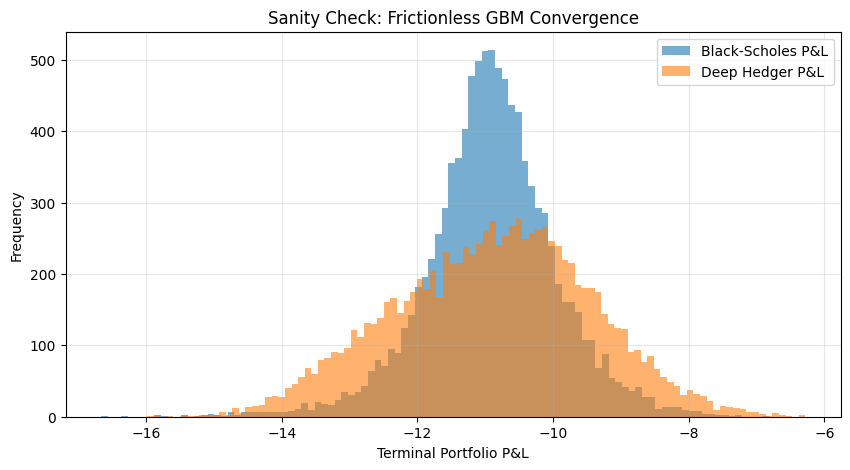

In [54]:
# 4. Sanity Check on Frictionless GBM
test_paths = generate_stock_paths(S0=S0_sim, r=r_sim, sigma=sigma_sim, T=T_sim, N_steps=N_steps_sim, N_paths=10000, mode='gbm')

# Evaluate Black-Scholes Performance
bs_pnl = simulate_bs_delta_hedge(test_paths, K_sim, r_sim, sigma_sim, T_sim, cost_rate=0.0)
# Evaluate Deep Hedger Performance
nh_pnl = deep_hedge_policy_eval(normalized_hedger, test_paths, K_sim, r_sim, T_sim, cost_rate=0.0)

# Compare Risk Metrics
bs_metrics = compute_risk_metrics(bs_pnl)
nh_metrics = compute_risk_metrics(nh_pnl)

import pandas as pd
comparison_df = pd.DataFrame({
    'Black-Scholes Delta': bs_metrics,
    'Normalized Deep Hedger': nh_metrics
})
display(comparison_df.round(4))

# Visualize P&L Distributions
plt.figure(figsize=(10, 5))
plt.hist(bs_pnl, bins=100, alpha=0.6, label='Black-Scholes P&L')
plt.hist(nh_pnl, bins=100, alpha=0.6, label='Deep Hedger P&L')
plt.title('Sanity Check: Frictionless GBM Convergence')
plt.xlabel('Terminal Portfolio P&L')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [55]:
def compute_risk_metrics(pnl_distribution, alpha=0.05):
    mean_pnl = np.mean(pnl_distribution)
    std_pnl = np.std(pnl_distribution) # Hedging Error

    # Value at Risk (VaR) and Conditional VaR (CVaR / Expected Shortfall)
    var_alpha = -np.percentile(pnl_distribution, alpha * 100)
    tail_losses = -pnl_distribution[pnl_distribution <= -var_alpha]
    cvar_alpha = np.mean(tail_losses) if len(tail_losses) > 0 else var_alpha

    return {
        'Mean P&L': mean_pnl,
        'Hedging Error (Std)': std_pnl,
        'VaR (95%)': var_alpha,
        'CVaR (95%)': cvar_alpha
    }